# Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

## Problem Statement

Type 2 Diabetes has become a growing public health concern in USA and many developed countries due to unhealthy dietary patterns, sedentary lifestyles, limited awareness, delayed diagnosis, and inadequate preventive healthcare systems. Many individuals remain undiagnosed until complications arise, resulting in increased healthcare costs and poor health outcomes.

Healthcare organizations and nutrition professionals often face challenges in identifying high-risk individuals early enough due to fragmented health records, limited predictive systems, and insufficient data-driven decision-making tools.

### Context Behind the Issue

The healthcare environment in USA is characterized by:


Increasing diabetes prevalence rates

High consumption of processed foods

Limited access to preventive healthcare services

Inconsistent nutrition monitoring systems

Manual health assessment processes

Lack of personalized nutrition intervention systems

Many healthcare facilities still rely on traditional assessment methods, making it difficult to predict diabetes risks efficiently and provide personalized preventive recommendations.

### Key Obstacles and Pain Points

Operational Inefficiencies

Manual patient assessment processes

Delayed identification of high-risk patients

Inconsistent dietary monitoring

Limited automation in health evaluation

## Aims
The project aims to achieve the following objectives:

Objective 1: Develop a Diabetes Risk Prediction Model

Design and train a machine learning model capable of predicting the likelihood of Type 2 Diabetes using patient health indicators and lifestyle variables.

Objective 2: Identify Key Risk Factors

Analyze the major contributors influencing diabetes risk, including glucose levels, BMI, age, insulin levels, physical activity, and dietary patterns.

Objective 3: Improve Preventive Healthcare Decision-Making

Enable healthcare professionals and individuals to make proactive decisions using predictive insights and nutrition recommendations.

## Data Dictionary

patient_id Integer
Unique identifier assigned to each patient

age - Integer
Age of the patient in years

gender-Categorical (String)
Biological sex of the patient (Male/Female)

bmi-Float
Body Mass Index calculated using weight and height

diabetes_type-Categorical (String)
Type of diabetes diagnosed (Type 1 or Type 2)

meal_time-Categorical (String)
Time category of meal consumed (Breakfast, Lunch, Dinner, Snack)

carb_intake-Float
Total carbohydrate intake for the meal in grams

protein_intake-Float
Total protein intake for the meal in grams

fat_intake-Float
Total fat intake for the meal in grams

fiber_intake-Float
Total dietary fiber intake for the meal in grams

sugar_intake-Float
Total sugar consumed during the meal in grams

glycemic_index-Float
Glycemic Index score of the meal indicating how quickly carbohydrates raise blood glucose

portion_size-Float
Estimated serving size of the meal in grams

water_intake-Float
Amount of water consumed during the meal in milliliters

insulin_dose-Float
Insulin dosage administered before or after meal

medication_adherence-Integer
Indicates whether patient adhered to prescribed medication (1 = Yes, 0 = No)

physical_activity-Float
Physical activity level measured in minutes of exercise per day

stress_level-Integer
Self-reported stress score on a scale of 1–10

sleep_hours-Float
Average number of hours slept before the meal period

smoking_status-Categorical (String)
Indicates whether the patient smokes (Yes/No)

alcohol_consumption-Categorical (String)

Indicates alcohol consumption behavior (Yes/No)

pre_meal_glucose-Float
Blood glucose reading before meal consumption (mg/dL)

post_meal_glucose-Float
Blood glucose reading after meal consumption (mg/dL)

glucose_change-Float
Difference between post-meal and pre-meal glucose levels

glycemic_load-Float
Calculated glycemic load of the meal

carb_fiber_ratio-Float
Ratio of carbohydrate intake to fiber intake

meal_risk_score-Float
Engineered nutritional risk score derived from meal composition

glucose_spike-Integer (Binary)
Target variable indicating whether a glucose spike occurred (1 = Spike, 0 = No Spike)

Import relevant libraries

In [1]:
# import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from collections import Counter

In [2]:
df = pd.read_csv('/Users/kabirmuhammad/Desktop/Amdari/NutriGlyc AI Project/Glucose_spike.csv')

In [3]:
df.head()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
0,1127,63,Male,25.318753,Type 2,Snack,206.078625,96.988928,81.332092,19.881550,...,6.038772,Yes,No,80.511484,185.125157,104.613673,139.121175,10.313445,2.057729,1
1,861,43,Female,29.887205,Type 1,Snack,110.277131,41.988332,65.323781,9.660801,...,7.787871,No,No,102.325117,101.612905,-0.712212,80.057182,11.297959,2.153776,0
2,1131,65,Female,21.831540,Type 1,Breakfast,88.692079,74.612428,26.828247,26.701083,...,9.146882,No,No,99.639334,123.456632,23.817298,46.809459,3.309272,1.309858,0
3,1096,56,Male,26.610861,Type 2,Dinner,168.193534,70.944312,58.451133,23.006694,...,5.856119,No,No,116.822669,122.497946,5.675277,127.919532,7.278996,2.061997,0
4,1045,58,Male,26.649132,Type 2,Dinner,93.580856,74.851625,14.576802,19.789018,...,7.327162,Yes,No,99.878155,98.419762,-1.458393,58.098774,4.705152,1.168034,0


## Data Cleaning 

In [4]:
df.columns

Index(['patient_id', 'age', 'gender', 'bmi', 'diabetes_type', 'meal_time',
       'carb_intake', 'protein_intake', 'fat_intake', 'fiber_intake',
       'sugar_intake', 'glycemic_index', 'portion_size', 'water_intake',
       'insulin_dose', 'medication_adherence', 'physical_activity',
       'stress_level', 'sleep_hours', 'smoking_status', 'alcohol_consumption',
       'pre_meal_glucose', 'post_meal_glucose', 'glucose_change',
       'glycemic_load', 'carb_fiber_ratio', 'meal_risk_score',
       'glucose_spike'],
      dtype='object')

In [5]:
df .info

<bound method DataFrame.info of       patient_id  age  gender        bmi diabetes_type  meal_time  \
0           1127   63    Male  25.318753        Type 2      Snack   
1            861   43  Female  29.887205        Type 1      Snack   
2           1131   65  Female  21.831540        Type 1  Breakfast   
3           1096   56    Male  26.610861        Type 2     Dinner   
4           1045   58    Male  26.649132        Type 2     Dinner   
...          ...  ...     ...        ...           ...        ...   
5145         128   52    Male  17.089172        Type 1      Snack   
5146         143   73    Male  27.745089        Type 2      Snack   
5147         803   65    Male  18.788603        Type 2     Dinner   
5148         246   79    Male  26.539871        Type 2      Snack   
5149         331   35  Female  24.051558        Type 2  Breakfast   

      carb_intake  protein_intake  fat_intake  fiber_intake  ...  sleep_hours  \
0      206.078625       96.988928   81.332092     19.88155

In [6]:
# investigate data types and data entries count to check for missing data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5150 non-null   int64  
 1   age                   5150 non-null   int64  
 2   gender                5150 non-null   object 
 3   bmi                   5150 non-null   float64
 4   diabetes_type         5150 non-null   object 
 5   meal_time             5150 non-null   object 
 6   carb_intake           5150 non-null   float64
 7   protein_intake        5150 non-null   float64
 8   fat_intake            5150 non-null   float64
 9   fiber_intake          4841 non-null   float64
 10  sugar_intake          5150 non-null   float64
 11  glycemic_index        5150 non-null   float64
 12  portion_size          5150 non-null   float64
 13  water_intake          5150 non-null   float64
 14  insulin_dose          4839 non-null   float64
 15  medication_adherence 

fiber intake, insulin dose, stress level, sleep hours dont have 5150 entries which means there might be missing data entries that need to be handled 

In [7]:
# Numerical and statistical analysis
df.describe()

,patient_id,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,...,physical_activity,stress_level,sleep_hours,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
count,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,4841.000000,5150.000000,5150.000000,5150.000000,...,5150.000000,4835.000000,4842.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000
mean,607.980583,48.338835,27.043032,122.520750,59.871306,49.812292,18.101458,46.040899,60.037362,399.110628,...,45.363254,5.478180,6.506480,110.739290,144.715815,33.976525,73.600590,9.751877,1.803309,0.465049
std,345.237485,17.861075,4.980009,58.018989,24.517150,19.601541,7.920562,24.135594,14.672699,120.325387,...,24.236189,2.867306,1.463630,13.543094,32.430293,29.207539,40.322001,12.266698,0.742337,0.498825
min,1.000000,18.000000,16.000000,10.000000,5.000000,5.000000,2.000000,0.000000,30.000000,100.000000,...,0.000000,1.000000,3.000000,70.000000,70.000000,-57.053540,3.000000,0.265554,0.391785,0.000000
25%,312.250000,33.000000,23.629638,81.484340,43.316316,36.355618,12.672105,29.083575,49.810095,319.418417,...,28.351598,3.000000,5.491062,102.024101,122.045551,12.884643,43.833275,4.151556,1.378861,0.000000
50%,616.000000,48.000000,26.986358,121.873969,59.168519,49.692208,17.983936,45.740657,59.860549,399.311839,...,44.866445,5.000000,6.506330,111.004625,143.084070,32.327095,69.551007,6.757980,1.697013,0.000000
75%,906.750000,64.000000,30.430209,163.937671,76.326848,62.698777,23.463788,62.027881,70.489454,478.161253,...,61.824295,8.000000,7.501433,119.941144,165.602878,52.266997,98.526361,10.428609,2.039949,1.000000
max,1200.000000,79.000000,44.093061,319.606832,148.563508,131.989007,48.209951,131.880984,100.000000,807.294680,...,141.502228,10.000000,10.000000,152.885870,273.804356,161.230116,271.344849,152.193730,9.660761,1.000000


The mean and median values for all the columns are all within range denoting a balanced data not skewed to any side

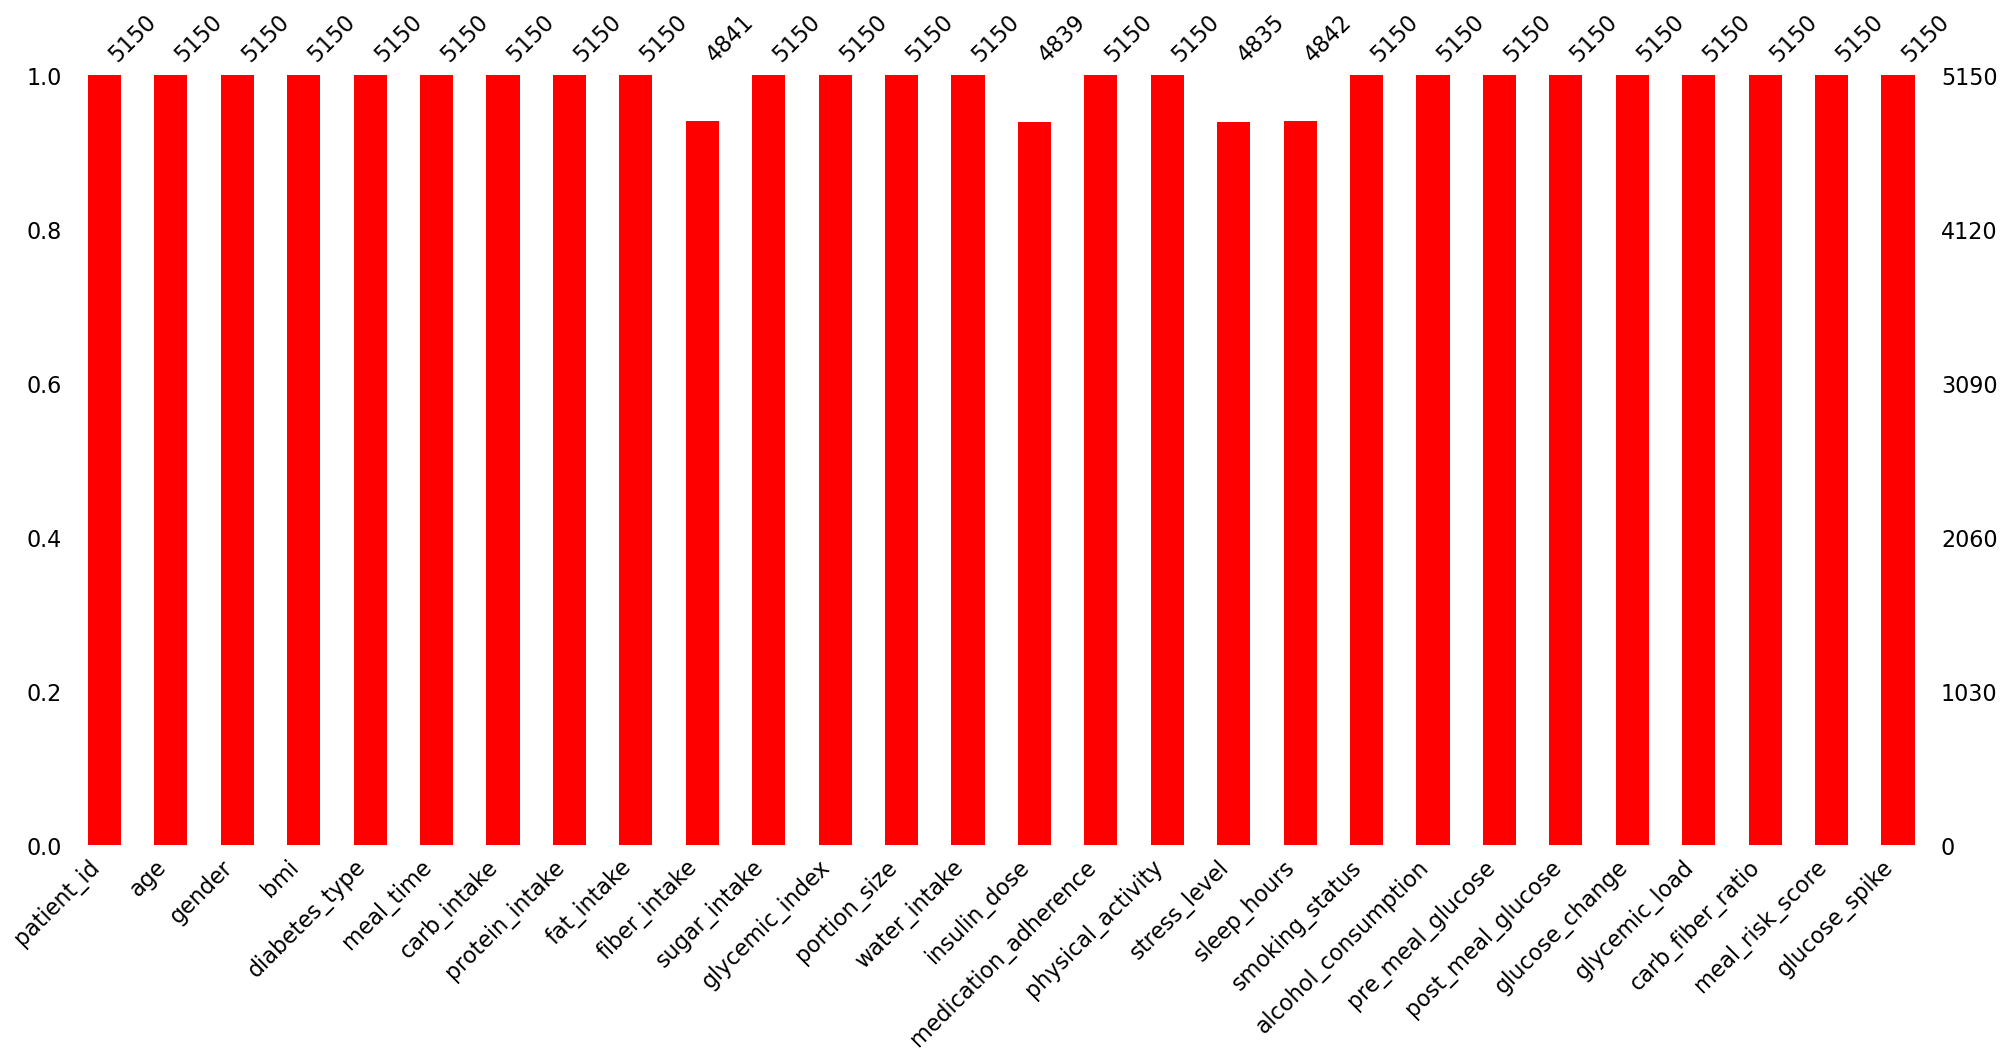

In [8]:
msno.bar(df, color="red"); # Check visually for any missing data

In [9]:
df[df.isnull().any(axis=1)]

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
14,806,53,Female,29.819169,Type 2,Dinner,57.160092,48.605818,77.303979,17.531498,...,6.187077,No,No,113.962146,120.724388,6.762242,38.527314,3.241931,1.026655,0
21,253,75,Female,30.750028,Type 1,Snack,124.626816,76.927840,56.568285,28.463052,...,7.205142,No,No,107.068295,122.105474,15.037179,45.225735,4.363218,1.248998,0
25,1083,62,Female,30.546246,Type 2,Snack,227.845078,48.632714,41.481049,NaN,...,4.900855,No,No,121.992517,234.235160,112.242643,68.353523,21.750719,2.147020,1
31,687,39,Female,22.549559,Type 1,Lunch,202.452979,72.862111,26.838453,10.002851,...,NaN,No,Yes,85.162844,139.026250,53.863405,152.228698,20.039192,2.641016,1
34,832,35,Male,25.260760,Type 2,Dinner,68.143700,60.523469,32.483476,NaN,...,6.035664,No,No,107.624558,109.584360,1.959802,32.821688,2.016789,1.246424,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5121,904,74,Female,28.745346,Type 2,Lunch,74.404246,53.881164,61.322177,9.755034,...,4.301847,Yes,No,112.816441,116.272300,3.455859,29.879031,7.549872,1.399393,0
5122,887,42,Male,21.517180,Type 2,Breakfast,112.975999,38.067852,82.028356,14.028437,...,NaN,Yes,No,120.676823,157.832677,37.155854,66.386404,7.996355,1.520469,1
5133,987,18,Male,30.661608,Type 2,Breakfast,73.148435,27.003337,52.066530,10.394562,...,NaN,No,No,113.567539,131.427396,17.859857,36.355909,6.970127,1.411807,0
5136,298,73,Female,28.449361,Type 2,Dinner,94.320573,48.363953,58.236036,12.764142,...,6.754865,No,No,117.589422,139.548695,21.959273,37.421027,7.332053,1.647486,0


In [10]:
null_vals = df.isnull().sum() # the null input count for each column
null_vals

patient_id                0
age                       0
gender                    0
bmi                       0
diabetes_type             0
meal_time                 0
carb_intake               0
protein_intake            0
fat_intake                0
fiber_intake            309
sugar_intake              0
glycemic_index            0
portion_size              0
water_intake              0
insulin_dose            311
medication_adherence      0
physical_activity         0
stress_level            315
sleep_hours             308
smoking_status            0
alcohol_consumption       0
pre_meal_glucose          0
post_meal_glucose         0
glucose_change            0
glycemic_load             0
carb_fiber_ratio          0
meal_risk_score           0
glucose_spike             0
dtype: int64

Text(0.5, 1.0, 'Boxplot on Sleep Hours')

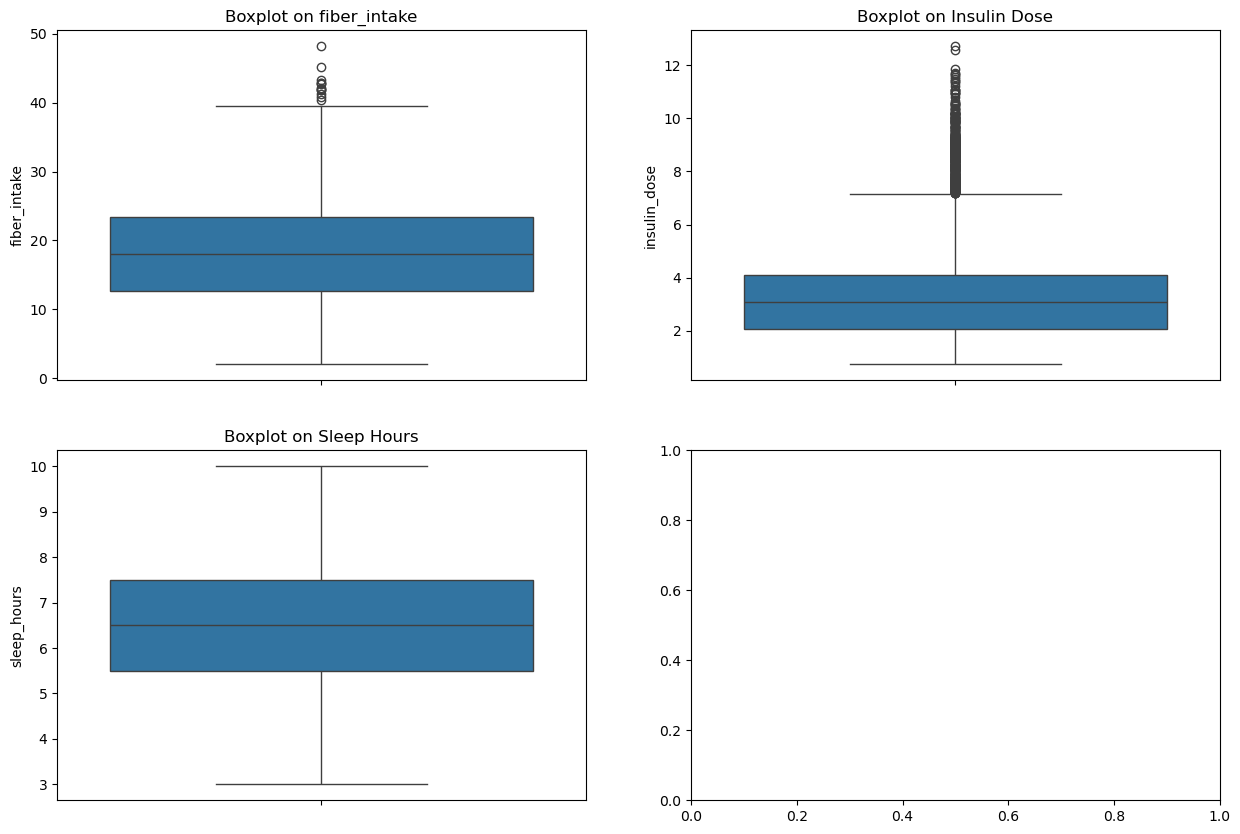

In [11]:
# Visualise data distribution to detrmine how to handle missing data
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,10))

sns.boxplot(y="fiber_intake", data=df, ax=axs[0,0])
axs[0,0].set_title("Boxplot on fiber_intake")

sns.boxplot(y="insulin_dose", data=df, ax=axs[0,1])
axs[0,1].set_title("Boxplot on Insulin Dose")

sns.boxplot(y="sleep_hours", data=df, ax=axs[1,0])
axs[1,0].set_title("Boxplot on Sleep Hours")

The 315 missing entries of stress level will be replaced with median stress level as its is a scale from 1-10 which should be categorical data.

Sleep hours will be replaced with mean value as data is balanced without any outliers. 

Fiber intake and Insulin dose columns will also be replaced with mean values as they account for just 6% of the data so not substantial enough to affect the balance of the data. 

In [12]:
# replace null values with average values and median values
df['insulin_dose'] = df['insulin_dose'].fillna(df['insulin_dose'].mean())
df['stress_level'] = df['stress_level'].fillna(df['stress_level'].median())
df['fiber_intake'] = df['fiber_intake'].fillna(df['fiber_intake'].mean())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].mean())

In [13]:
null_vals = df.isnull().sum() # the null input count for each column
null_vals

patient_id              0
age                     0
gender                  0
bmi                     0
diabetes_type           0
meal_time               0
carb_intake             0
protein_intake          0
fat_intake              0
fiber_intake            0
sugar_intake            0
glycemic_index          0
portion_size            0
water_intake            0
insulin_dose            0
medication_adherence    0
physical_activity       0
stress_level            0
sleep_hours             0
smoking_status          0
alcohol_consumption     0
pre_meal_glucose        0
post_meal_glucose       0
glucose_change          0
glycemic_load           0
carb_fiber_ratio        0
meal_risk_score         0
glucose_spike           0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5150 non-null   int64  
 1   age                   5150 non-null   int64  
 2   gender                5150 non-null   object 
 3   bmi                   5150 non-null   float64
 4   diabetes_type         5150 non-null   object 
 5   meal_time             5150 non-null   object 
 6   carb_intake           5150 non-null   float64
 7   protein_intake        5150 non-null   float64
 8   fat_intake            5150 non-null   float64
 9   fiber_intake          5150 non-null   float64
 10  sugar_intake          5150 non-null   float64
 11  glycemic_index        5150 non-null   float64
 12  portion_size          5150 non-null   float64
 13  water_intake          5150 non-null   float64
 14  insulin_dose          5150 non-null   float64
 15  medication_adherence 

In [15]:
df.duplicated().sum()

np.int64(150)

In [16]:
df=df.drop_duplicates().reset_index(drop=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['age'].unique()

array([63, 43, 65, 56, 58, 21, 47, 39, 28, 19, 61, 29, 53, 35, 70, 24, 78,
       18, 75, 40, 62, 23, 25, 41, 36, 54, 48, 79, 74, 59, 50, 27, 71, 44,
       26, 38, 72, 46, 60, 32, 69, 20, 55, 76, 66, 51, 42, 33, 31, 45, 49,
       68, 22, 64, 52, 30, 37, 77, 73, 67, 34, 57])

Group ages according to categories for easier analysis

In [19]:
def age_group(x):
    if x <= 25:
        return "<-25 Young Person"
    elif x <= 40:
        return "25-40 Adult"
    elif x <=50:
        return "40-50 Old Adults"
    elif x >= 51:
        return ">=51 Elders"

# Apply function to data
df['age_group'] = df['age'].apply(age_group)
df.head()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike,age_group
0,1127,63,Male,25.318753,Type 2,Snack,206.078625,96.988928,81.332092,19.881550,...,Yes,No,80.511484,185.125157,104.613673,139.121175,10.313445,2.057729,1,>=51 Elders
1,861,43,Female,29.887205,Type 1,Snack,110.277131,41.988332,65.323781,9.660801,...,No,No,102.325117,101.612905,-0.712212,80.057182,11.297959,2.153776,0,40-50 Old Adults
2,1131,65,Female,21.831540,Type 1,Breakfast,88.692079,74.612428,26.828247,26.701083,...,No,No,99.639334,123.456632,23.817298,46.809459,3.309272,1.309858,0,>=51 Elders
3,1096,56,Male,26.610861,Type 2,Dinner,168.193534,70.944312,58.451133,23.006694,...,No,No,116.822669,122.497946,5.675277,127.919532,7.278996,2.061997,0,>=51 Elders
4,1045,58,Male,26.649132,Type 2,Dinner,93.580856,74.851625,14.576802,19.789018,...,Yes,No,99.878155,98.419762,-1.458393,58.098774,4.705152,1.168034,0,>=51 Elders


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   bmi                   5000 non-null   float64
 4   diabetes_type         5000 non-null   object 
 5   meal_time             5000 non-null   object 
 6   carb_intake           5000 non-null   float64
 7   protein_intake        5000 non-null   float64
 8   fat_intake            5000 non-null   float64
 9   fiber_intake          5000 non-null   float64
 10  sugar_intake          5000 non-null   float64
 11  glycemic_index        5000 non-null   float64
 12  portion_size          5000 non-null   float64
 13  water_intake          5000 non-null   float64
 14  insulin_dose          5000 non-null   float64
 15  medication_adherence 

In [21]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [22]:
df['diabetes_type'].unique()

array(['Type 2', 'Type 1'], dtype=object)

In [23]:
df['meal_time'].unique()

array(['Snack', 'Breakfast', 'Dinner', 'Lunch'], dtype=object)

In [24]:
df['smoking_status'].unique()

array(['Yes', 'No'], dtype=object)

In [25]:
df['alcohol_consumption'].unique()

array(['No', 'Yes'], dtype=object)

In [26]:
df['age_group'].unique()

array(['>=51 Elders', '40-50 Old Adults', '<-25 Young Person',
       '25-40 Adult'], dtype=object)

In [27]:
df['medication_adherence'].unique()

array([1, 0])

In [28]:
df['stress_level'] = df['stress_level'].astype(object)

## Univariate Analysis

[Text(0, 0, '2623'), Text(0, 0, '2377')]

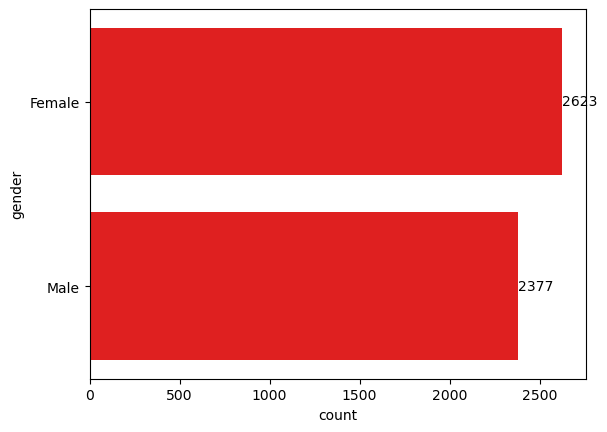

In [29]:
# Lets see our patients distribution by gender
ax = sns.countplot(y='gender', data=df, color='red', order=df['gender'].value_counts(ascending=False).index)
values = df['gender'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

Observation
Out of 5150 Patients, 2695 Patients were female while 2455 patients were Male showing there isnt any significant difference between patients that were male or female

[Text(0, 0, '2311'), Text(0, 0, '1257'), Text(0, 0, '795'), Text(0, 0, '637')]

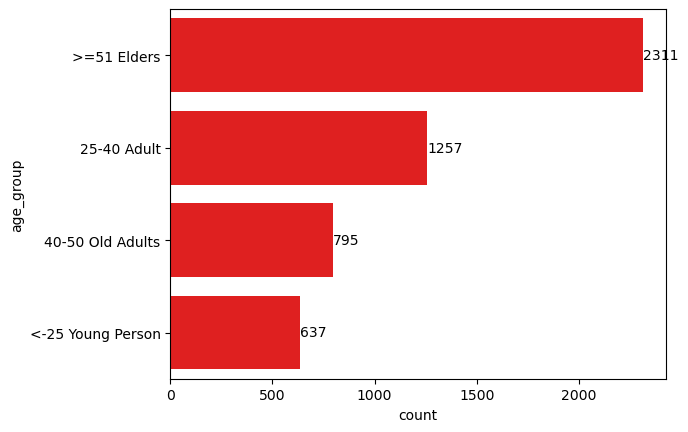

In [30]:
# Lets see distribution by age group
ax = sns.countplot(y='age_group', data=df, color='red', order=df['age_group'].value_counts(ascending=False).index)
values = df['age_group'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

### Observation
Out of 5150 paients the age group most patients were elders above 51 years old.

There were 1295 adult patients who aged between 25 and 40

There were 823 Old adults between 40-50 and 650 young patients beow 25 years old. 

[Text(0, 0, '4268'), Text(0, 0, '732')]

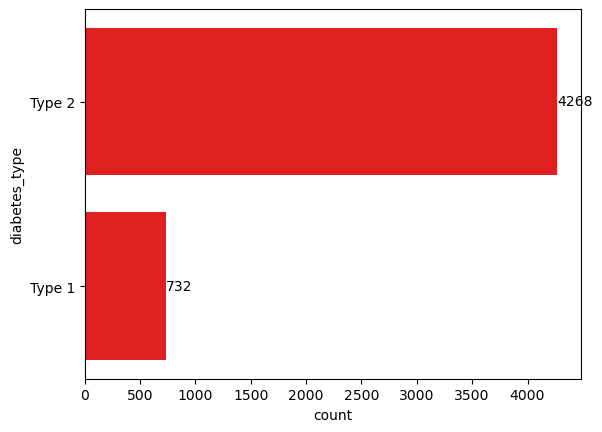

In [31]:
ax = sns.countplot(y='diabetes_type', data=df, color='red', order=df['diabetes_type'].value_counts(ascending=False).index )
values = df['diabetes_type'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

Of the total 5150 patients, only 753 patients had Type 1 Diabetes. A significant number of of the patients had Type 2 Diabetes. 

[Text(0, 0, '1295'),
 Text(0, 0, '1241'),
 Text(0, 0, '1234'),
 Text(0, 0, '1230')]

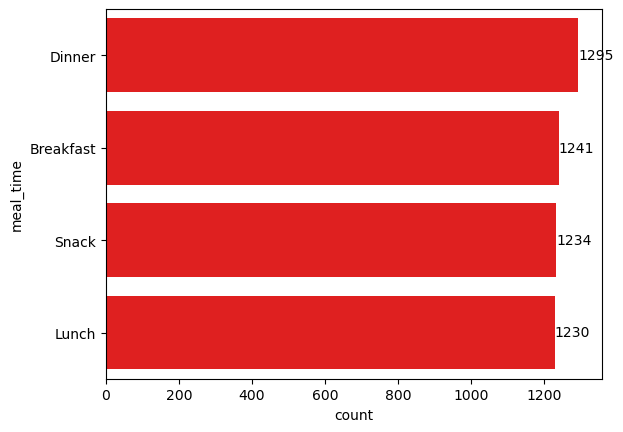

In [32]:
ax = sns.countplot(y='meal_time', data=df, color='red', order=df['meal_time'].value_counts(ascending=False).index )
values = df['meal_time'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

### Observation
There were relatively same numebr of patients that took each meal at different times of the day. 

[Text(0, 0, '4005'), Text(0, 0, '995')]

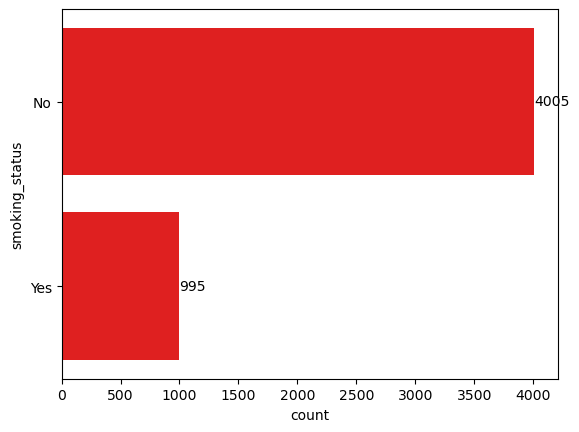

In [33]:
ax = sns.countplot(y='smoking_status', data=df, color='red', order=df['smoking_status'].value_counts(ascending=False).index )
values = df['smoking_status'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

[Text(0, 0, '3719'), Text(0, 0, '1281')]

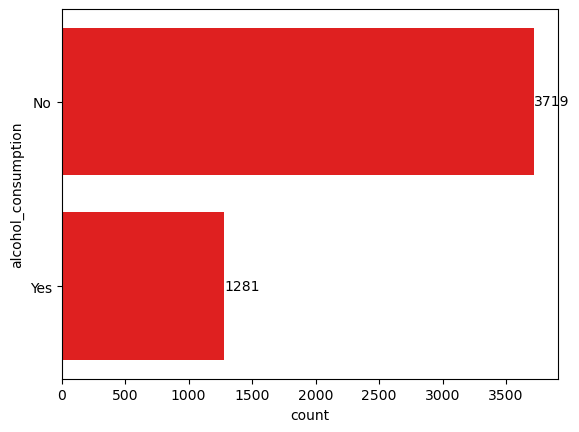

In [34]:
ax = sns.countplot(y='alcohol_consumption', data=df, color='red', order=df['alcohol_consumption'].value_counts(ascending=False).index )
values = df['alcohol_consumption'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

[Text(0, 0, '4053'), Text(0, 0, '947')]

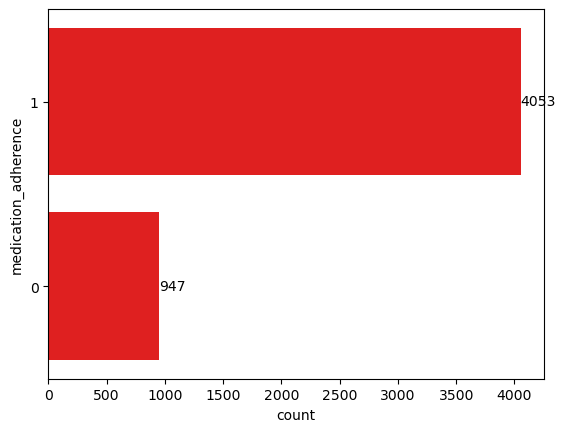

In [35]:
ax = sns.countplot(y='medication_adherence', data=df, color='red', order=df['medication_adherence'].value_counts(ascending=False).index )
values = df['medication_adherence'].value_counts(ascending=False).values 
ax.bar_label(container=ax.containers[0], labels=values)

## Observation 
Most of the patients adhered to thier medication. Only 978 patients werent as dedicated.  

In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   bmi                   5000 non-null   float64
 4   diabetes_type         5000 non-null   object 
 5   meal_time             5000 non-null   object 
 6   carb_intake           5000 non-null   float64
 7   protein_intake        5000 non-null   float64
 8   fat_intake            5000 non-null   float64
 9   fiber_intake          5000 non-null   float64
 10  sugar_intake          5000 non-null   float64
 11  glycemic_index        5000 non-null   float64
 12  portion_size          5000 non-null   float64
 13  water_intake          5000 non-null   float64
 14  insulin_dose          5000 non-null   float64
 15  medication_adherence 

In [37]:
df['glucose_spike'].unique()

array([1, 0])

In [38]:
df['glucose_change'].unique()

array([104.6136725 ,  -0.71221183,  23.81729786, ...,  48.56422609,
        48.78766748,  31.94345146])

In [39]:
df['medication_adherence'].unique()

array([1, 0])

In [40]:
df['glucose_spike'].unique()

array([1, 0])

In [41]:
df['smoking_status'].unique()


array(['Yes', 'No'], dtype=object)

In [42]:
df['alcohol_consumption'].unique()

array(['No', 'Yes'], dtype=object)

In [43]:
df["medication_adherence"] = df["medication_adherence"].astype(bool)
df["glucose_spike"] = df["glucose_spike"].astype(bool)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   bmi                   5000 non-null   float64
 4   diabetes_type         5000 non-null   object 
 5   meal_time             5000 non-null   object 
 6   carb_intake           5000 non-null   float64
 7   protein_intake        5000 non-null   float64
 8   fat_intake            5000 non-null   float64
 9   fiber_intake          5000 non-null   float64
 10  sugar_intake          5000 non-null   float64
 11  glycemic_index        5000 non-null   float64
 12  portion_size          5000 non-null   float64
 13  water_intake          5000 non-null   float64
 14  insulin_dose          5000 non-null   float64
 15  medication_adherence 

In [44]:
df['meal_risk_score'].unique()

array([2.05772876, 2.15377617, 1.30985831, ..., 1.85100883, 0.97378344,
       1.81380263])

In [45]:
df['physical_activity'].unique()


array([31.38407543, 48.11294962, 32.940728  , ..., 50.33698756,
       11.75011782, 17.24826073])

Text(0.5, 1.0, 'Meal Risk Score by Glucose Spike')

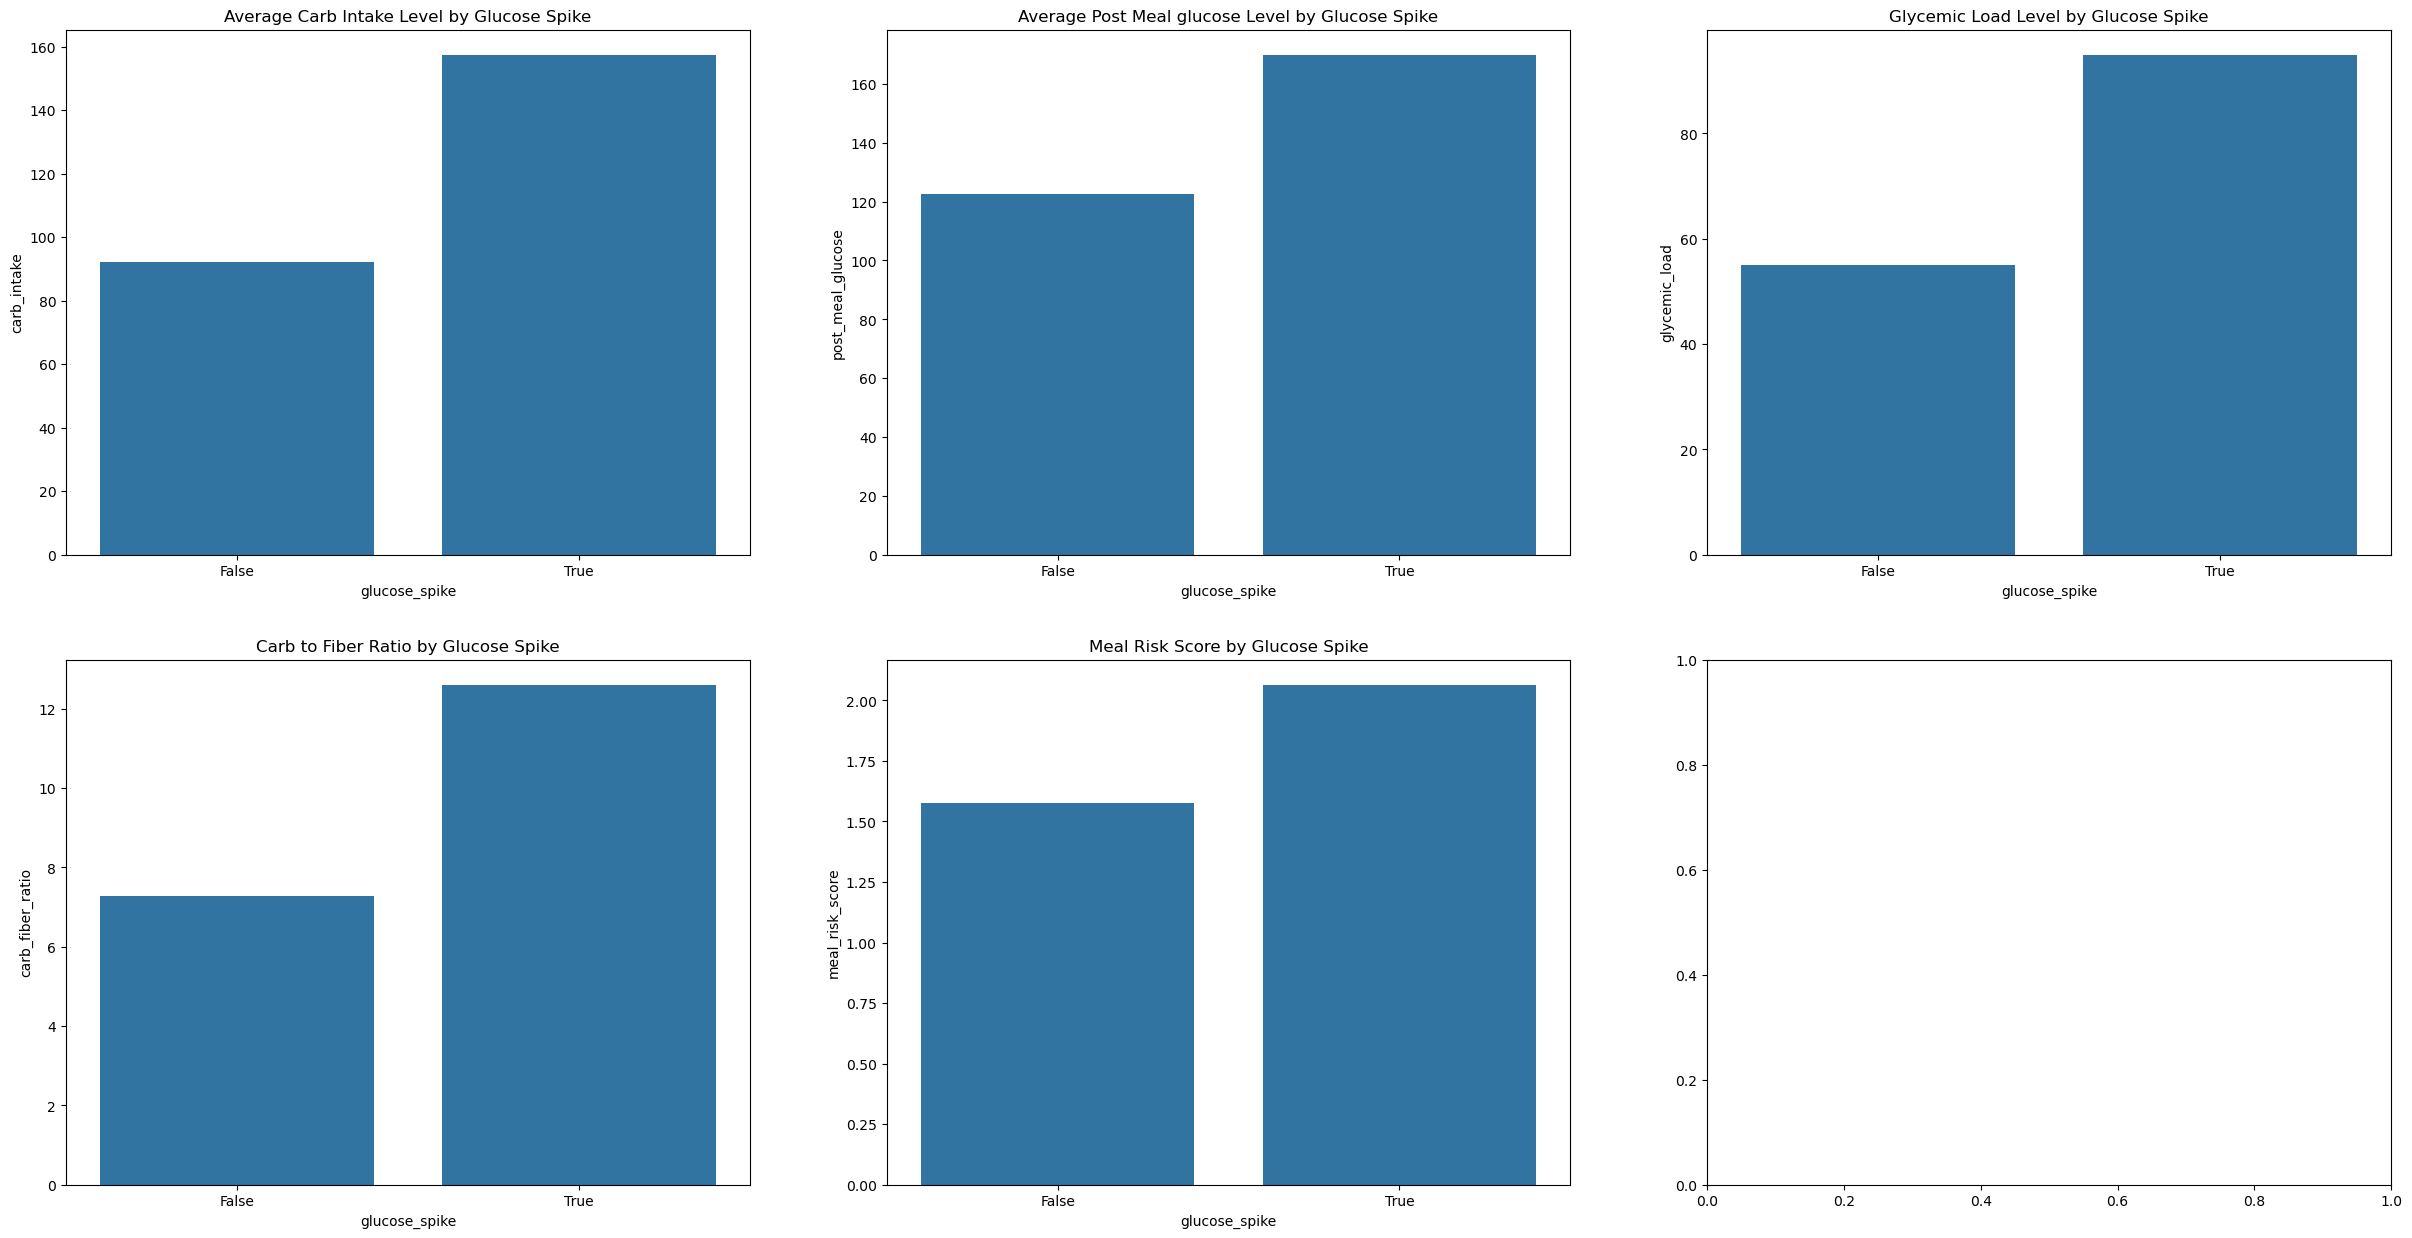

In [46]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(30, 15))

ap = df.groupby("glucose_spike")["carb_intake"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =ap, y= 'carb_intake', ax=axs[0,0])
axs[0,0].set_title("Average Carb Intake Level by Glucose Spike")

bp= df.groupby("glucose_spike")["post_meal_glucose"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =bp, y= 'post_meal_glucose', ax=axs[0,1])
axs[0,1].set_title("Average Post Meal glucose Level by Glucose Spike")

ep = df.groupby("glucose_spike")["glycemic_load"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =ep, y= 'glycemic_load', ax=axs[0,2])
axs[0,2].set_title("Glycemic Load Level by Glucose Spike")

fp = df.groupby("glucose_spike")["carb_fiber_ratio"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =fp, y= 'carb_fiber_ratio', ax=axs[1,0])
axs[1,0].set_title("Carb to Fiber Ratio by Glucose Spike")

gp = df.groupby("glucose_spike")["meal_risk_score"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =gp, y= 'meal_risk_score', ax=axs[1,1])
axs[1,1].set_title("Meal Risk Score by Glucose Spike")


Carbohydrate intake emerged as the single strongest predictor in the entire dataset. Patients with high carb consumption spiked. Those with lower carb intake largely did not. This is not surprising clinically, but the data quantifies it in a way that gives us confidence to act on it.

Closely related were glycemic load and the carb-to-fiber ratio. These two variables tell the same story from different angles.it is not just how many carbs a patient eats, but how fast those carbs hit the bloodstream. A high glycemic load means rapid glucose absorption. A high carb-to-fiber ratio means not enough fiber is present to slow that absorption down. Together, they paint a picture of meals that overwhelm the body's glucose regulation system.

The meal risk score and post-meal glucose levels reinforced this pattern further. Patients flagged with higher meal risk scores almost always ended up in the spike group. The data is essentially confirming that the quality and composition of a meal matters enormously not just its size.

Text(0.5, 1.0, 'Glucose Change Level by Glucose Spike')

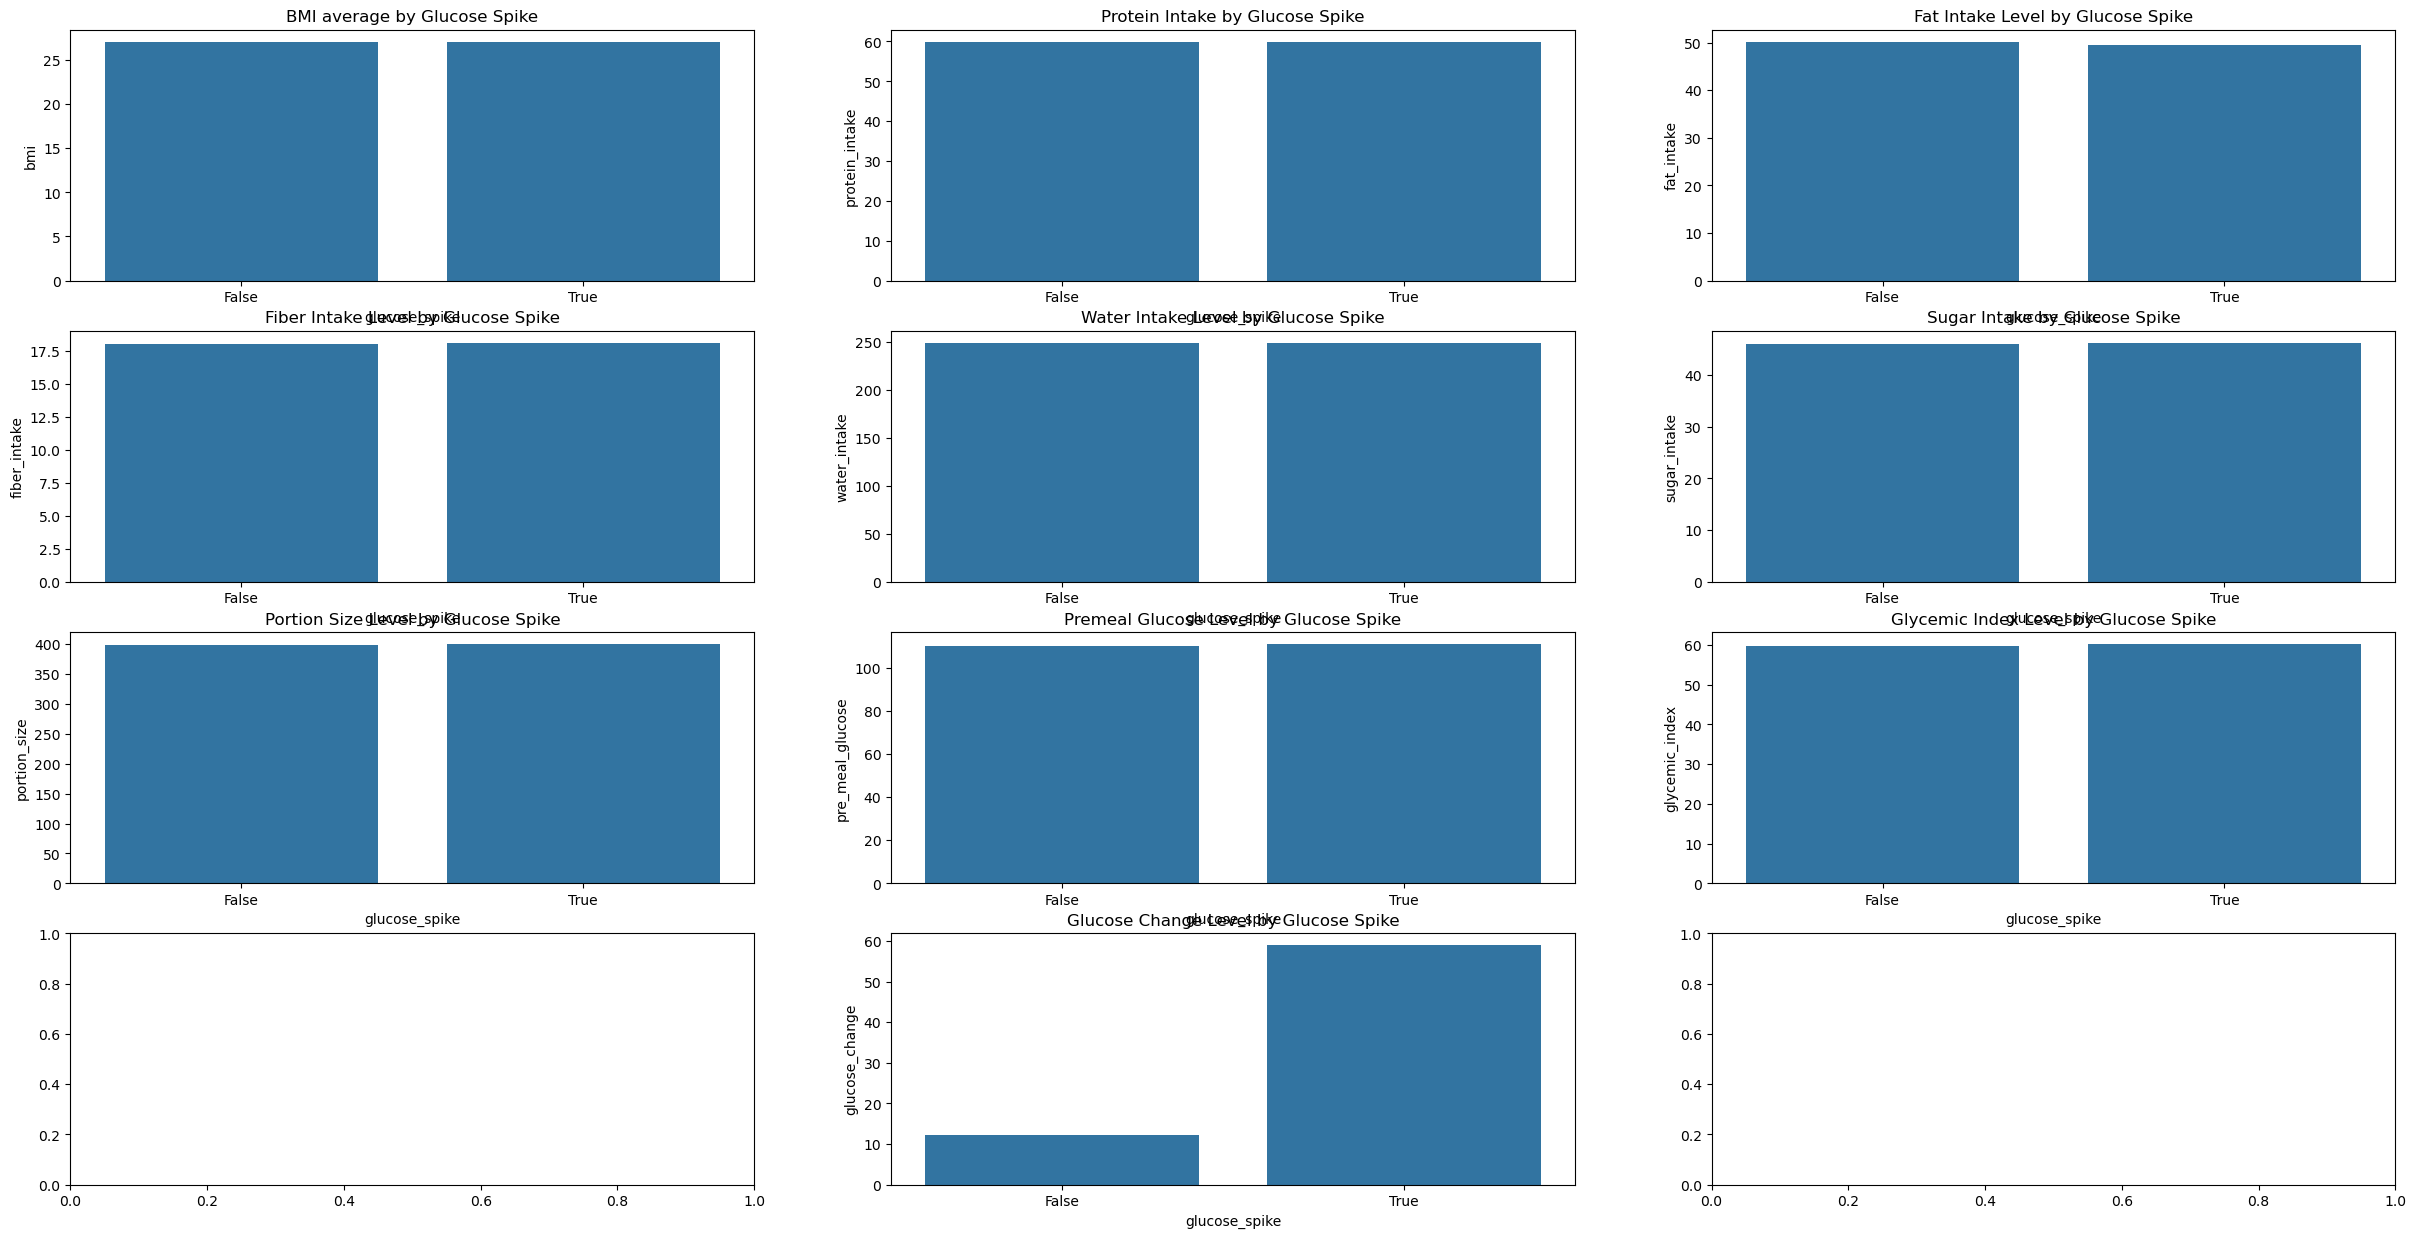

In [47]:
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(30, 15))

bp= df.groupby("glucose_spike")["bmi"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =bp, y= 'bmi', ax=axs[0,0])
axs[0,0].set_title("BMI average by Glucose Spike")

cp = df.groupby("glucose_spike")["protein_intake"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =cp, y= 'protein_intake', ax=axs[0,1])
axs[0,1].set_title("Protein Intake by Glucose Spike")

hp = df.groupby("glucose_spike")["fat_intake"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =hp, y= 'fat_intake', ax=axs[0,2])
axs[0,2].set_title("Fat Intake Level by Glucose Spike")

dp = df.groupby("glucose_spike")["fiber_intake"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =dp, y= 'fiber_intake', ax=axs[1,0])
axs[1,0].set_title("Fiber Intake Level by Glucose Spike")

lp = df.groupby("glucose_spike")["water_intake"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =lp, y= 'water_intake', ax=axs[1,1])
axs[1,1].set_title("Water Intake Level by Glucose Spike")

ip = df.groupby("glucose_spike")["sugar_intake"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =ip, y= 'sugar_intake', ax=axs[1,2])
axs[1,2].set_title("Sugar Intake by Glucose Spike")

mp = df.groupby("glucose_spike")["portion_size"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =mp, y= 'portion_size', ax=axs[2,0])
axs[2,0].set_title("Portion Size Level by Glucose Spike")

np = df.groupby("glucose_spike")["pre_meal_glucose"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =np, y= 'pre_meal_glucose', ax=axs[2,1])
axs[2,1].set_title("Premeal Glucose Level by Glucose Spike")

op = df.groupby("glucose_spike")["glycemic_index"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =op, y= 'glycemic_index', ax=axs[2,2])
axs[2,2].set_title("Glycemic Index Level by Glucose Spike")

qp = df.groupby("glucose_spike")["glucose_change"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =qp, y= 'glucose_change', ax=axs[3,1])
axs[3,1].set_title("Glucose Change Level by Glucose Spike")

BMI, protein intake, fat intake, fiber intake, water intake, sugar intake, portion size, pre-meal glucose levels, glycemic index, and glucose change — none of these showed a statistically significant relationship with whether a patient spiked or not.

This does not mean these variables are clinically irrelevant in a broader sense. What it does mean is that within this patient population and this dataset, they did not differentiate spike patients from non-spike patients. That is a useful finding in itself — it tells us where not to focus intervention resources, and it challenges some assumptions we might have held going in.

Text(0.5, 1.0, 'Physical Activity by Glucose Spike')

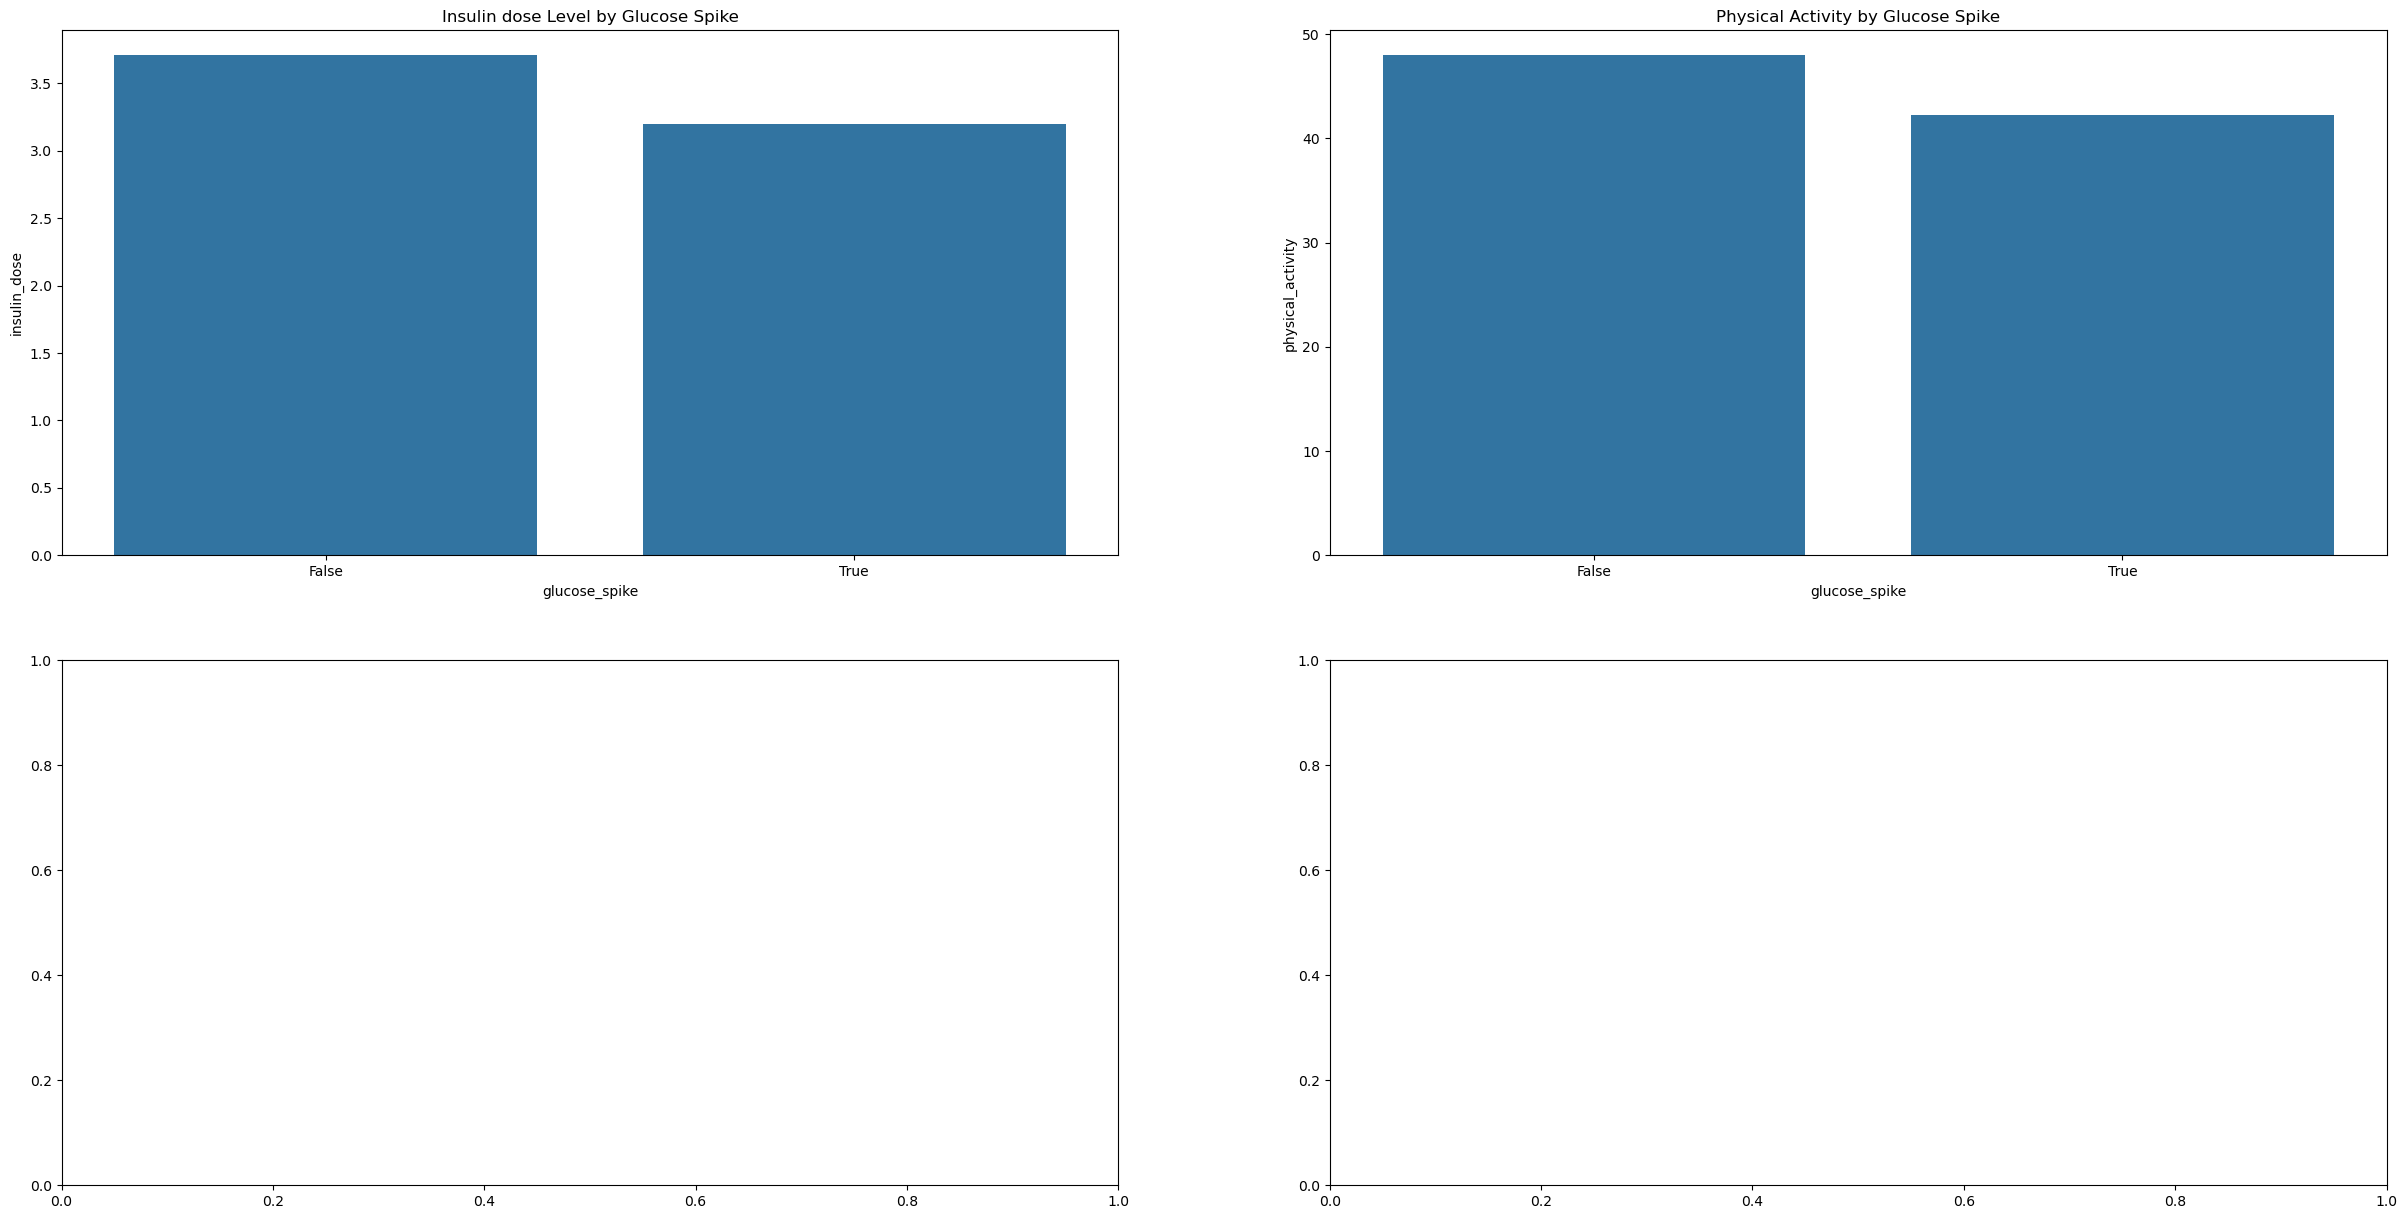

In [48]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(30, 15))

rp = df.groupby("glucose_spike")["insulin_dose"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =rp, y= 'insulin_dose', ax=axs[0,0])
axs[0,0].set_title("Insulin dose Level by Glucose Spike")

sp = df.groupby("glucose_spike")["physical_activity"].mean().reset_index()
sns.barplot(x = 'glucose_spike', data =sp, y= 'physical_activity', ax=axs[0,1])
axs[0,1].set_title("Physical Activity by Glucose Spike")


BMI, protein intake, fat intake, fiber intake, water intake, sugar intake, portion size, pre-meal glucose levels, glycemic index, and glucose change — none of these showed a statistically significant relationship with whether a patient spiked or not.
This does not mean these variables are clinically irrelevant in a broader sense. What it does mean is that within this patient population and this dataset, they did not differentiate spike patients from non-spike patients. That is a useful finding in itself — it tells us where not to focus intervention resources, and it challenges some assumptions we might have held going in.

Patients who received higher insulin doses were significantly less likely to experience a glucose spike. This validates what clinicians already know.
Physical activity told an equally compelling story. Patients with higher physical activity levels largely avoided spikes. The body's ability to utilise glucose improves with movement, and the data reflects this directly. This makes physical activity not just a lifestyle recommendation but a clinically measurable protective factor in this dataset

Drop less relevant features

Handle Duplicate Data 

Handle Outliers

Encode Categorical Variables

Scale Numerical Variables

Check and Handle Class Imbalance by Oversampling with SMOTE

Data Splitting

Model Selection

Model Evaluation

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   bmi                   5000 non-null   float64
 4   diabetes_type         5000 non-null   object 
 5   meal_time             5000 non-null   object 
 6   carb_intake           5000 non-null   float64
 7   protein_intake        5000 non-null   float64
 8   fat_intake            5000 non-null   float64
 9   fiber_intake          5000 non-null   float64
 10  sugar_intake          5000 non-null   float64
 11  glycemic_index        5000 non-null   float64
 12  portion_size          5000 non-null   float64
 13  water_intake          5000 non-null   float64
 14  insulin_dose          5000 non-null   float64
 15  medication_adherence 

In [51]:
df = df.drop(columns=['patient_id', 'glucose_change', 'age_group'] )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   gender                5000 non-null   object 
 2   bmi                   5000 non-null   float64
 3   diabetes_type         5000 non-null   object 
 4   meal_time             5000 non-null   object 
 5   carb_intake           5000 non-null   float64
 6   protein_intake        5000 non-null   float64
 7   fat_intake            5000 non-null   float64
 8   fiber_intake          5000 non-null   float64
 9   sugar_intake          5000 non-null   float64
 10  glycemic_index        5000 non-null   float64
 11  portion_size          5000 non-null   float64
 12  water_intake          5000 non-null   float64
 13  insulin_dose          5000 non-null   float64
 14  medication_adherence  5000 non-null   bool   
 15  physical_activity    

glucose_change is dropped because the pre_meal and post meal glucose features already account for the change.

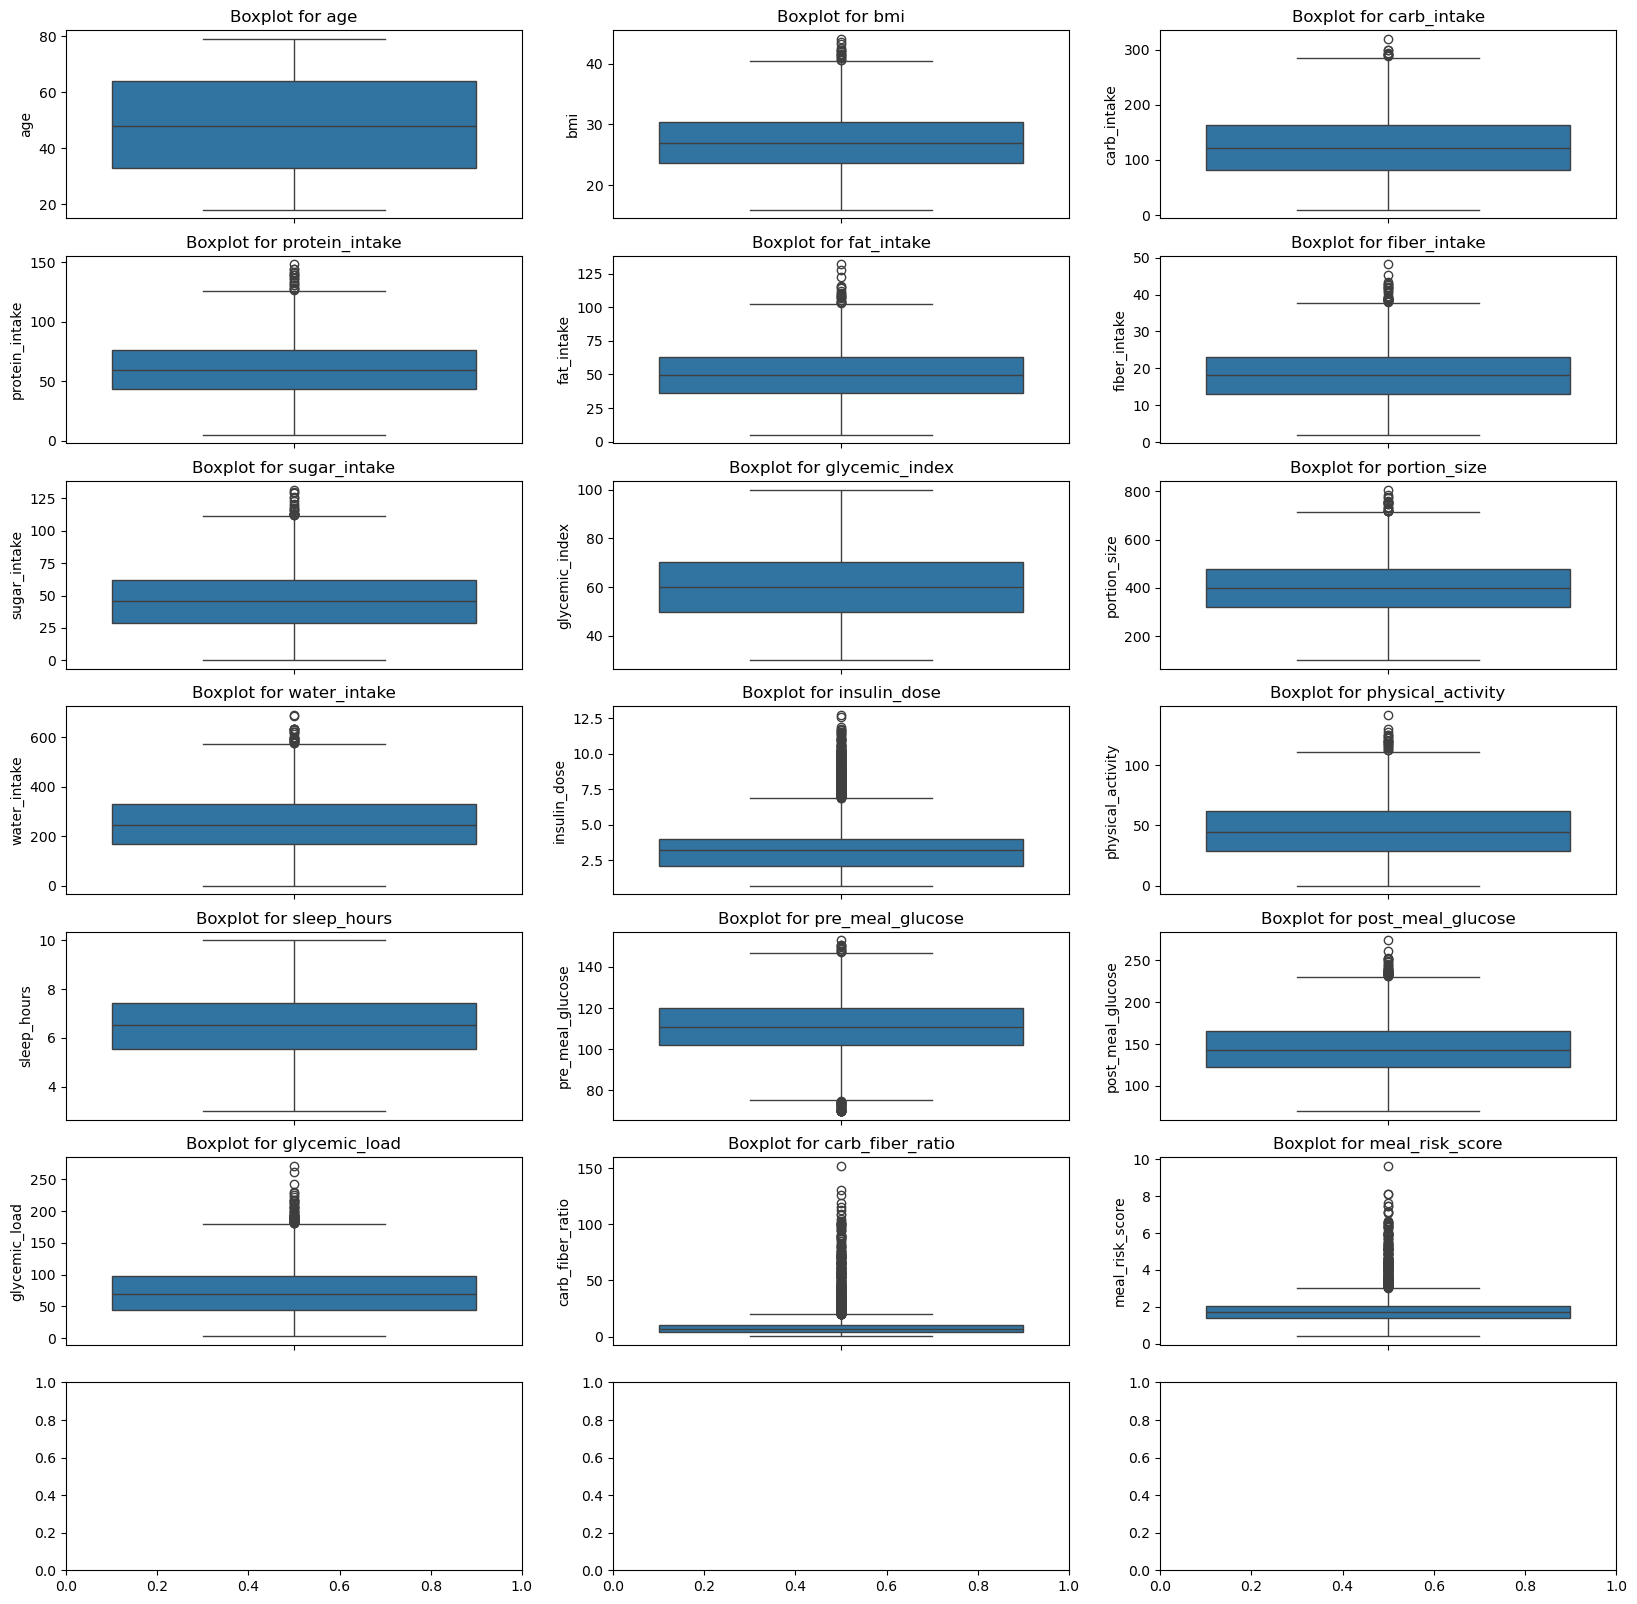

In [52]:
# Handle Outliers
numerical_data =df.select_dtypes(include='number')
fig, ax= plt.subplots(nrows=7, ncols=3, figsize=(20, 20))
ax=ax.flatten()
for idx, col in enumerate(numerical_data):
    sns.boxplot(df[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

bmi
portion_size
water_intake
insulin_dose
physical_activity
glucose_change
glycemic_load
carb_fiber ratio
meal_risk_score

In [53]:
affected_columns = ['bmi',
                    'carb_intake',
                    'fat_intake',
                    'protein_intake',
                    'fiber_intake',
                    'sugar_intake',
                    'portion_size', 
                    'water_intake', 
                    'insulin_dose', 
                    'physical_activity', 
                    'pre_meal_glucose',
                    'post_meal_glucose',
                    'glycemic_load', 
                    'carb_fiber_ratio', 
                    'meal_risk_score']

In [54]:
q1 = df[affected_columns].quantile(0.25)
q3 = df[affected_columns].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
df[affected_columns] = df[affected_columns].clip(lower=lower_bound, upper=upper_bound, axis = 1)

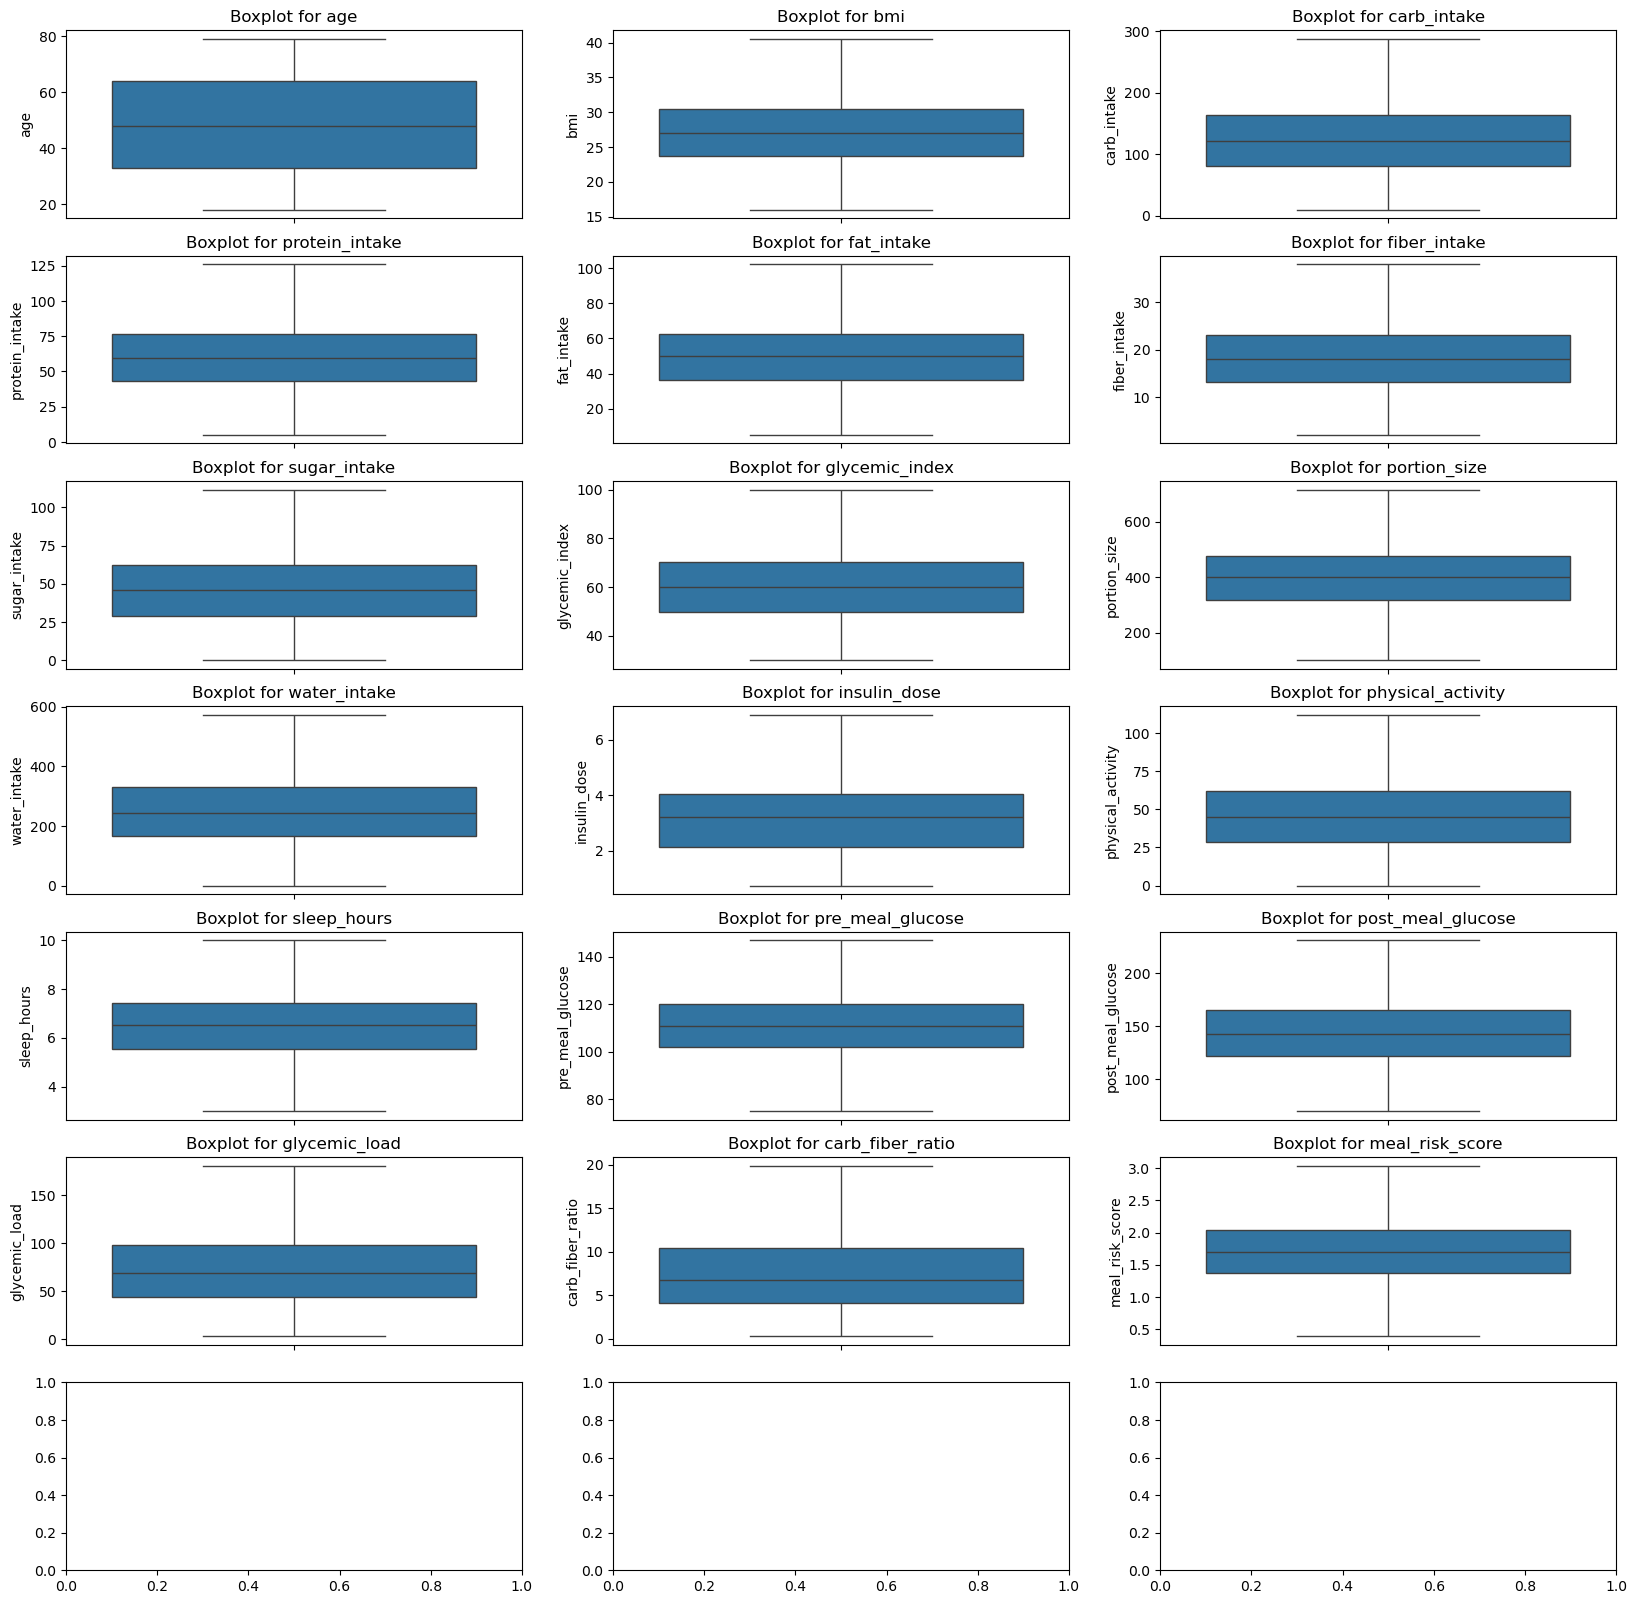

In [55]:

fig, ax= plt.subplots(nrows=7, ncols=3, figsize=(20, 20))
ax=ax.flatten()
for idx, col in enumerate(numerical_data):
    sns.boxplot(df[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

## Encoding Categorical Variables

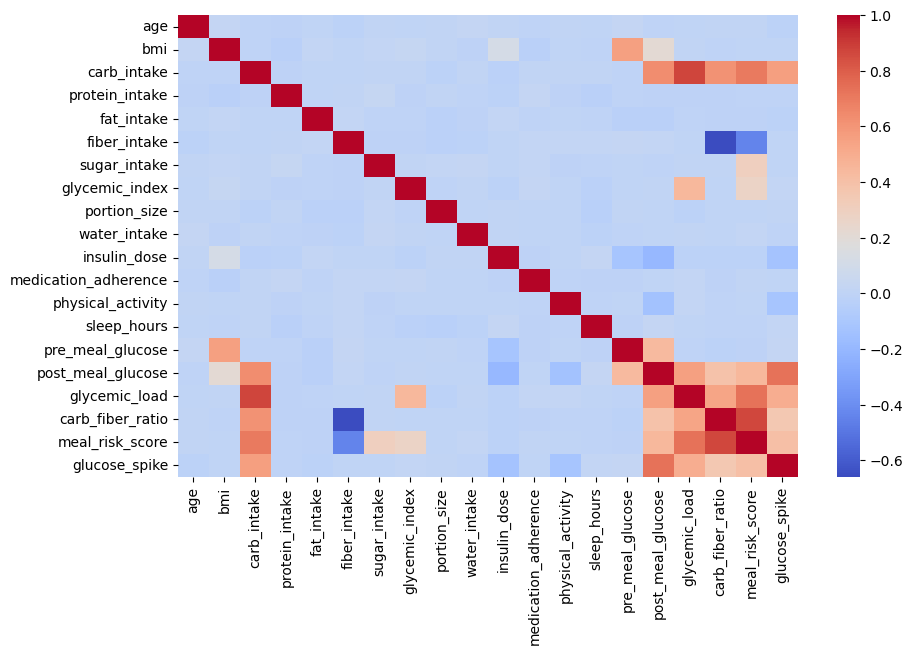

In [56]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.show()

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   gender                5000 non-null   object 
 2   bmi                   5000 non-null   float64
 3   diabetes_type         5000 non-null   object 
 4   meal_time             5000 non-null   object 
 5   carb_intake           5000 non-null   float64
 6   protein_intake        5000 non-null   float64
 7   fat_intake            5000 non-null   float64
 8   fiber_intake          5000 non-null   float64
 9   sugar_intake          5000 non-null   float64
 10  glycemic_index        5000 non-null   float64
 11  portion_size          5000 non-null   float64
 12  water_intake          5000 non-null   float64
 13  insulin_dose          5000 non-null   float64
 14  medication_adherence  5000 non-null   bool   
 15  physical_activity    

Label Encoding for gender, diabetes_type, medication_adherence, smoking_status, alcohol_consumption

One-hot Encoding for meal_time

In [58]:
from sklearn.preprocessing import LabelEncoder
# Label Encoding for binary features
label_enc = LabelEncoder() # Initialise Encoder
df['gender'] = label_enc.fit_transform(df['gender'])
df['diabetes_type'] = label_enc.fit_transform(df['diabetes_type'])
df['medication_adherence'] = label_enc.fit_transform(df['medication_adherence'])
df['smoking_status'] = label_enc.fit_transform(df['smoking_status'])
df['alcohol_consumption'] = label_enc.fit_transform(df['alcohol_consumption'])
df['glucose_spike'] = label_enc.fit_transform(df['glucose_spike'])
# One hot encoding for other categorical variables
df = pd.get_dummies(df, columns=['meal_time'])

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   gender                5000 non-null   int64  
 2   bmi                   5000 non-null   float64
 3   diabetes_type         5000 non-null   int64  
 4   carb_intake           5000 non-null   float64
 5   protein_intake        5000 non-null   float64
 6   fat_intake            5000 non-null   float64
 7   fiber_intake          5000 non-null   float64
 8   sugar_intake          5000 non-null   float64
 9   glycemic_index        5000 non-null   float64
 10  portion_size          5000 non-null   float64
 11  water_intake          5000 non-null   float64
 12  insulin_dose          5000 non-null   float64
 13  medication_adherence  5000 non-null   int64  
 14  physical_activity     5000 non-null   float64
 15  stress_level         

## Scale Numerical Features
age, bmi, glycemic index, portion_size, water_intake, insulin_dose, physical_activity, stress_level, sleep_hours, glucose_change, glycemicload, carb_to_fiber_ratio, meal_risk_score

In [60]:
df.head()

,age,gender,bmi,diabetes_type,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,...,pre_meal_glucose,post_meal_glucose,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike,meal_time_Breakfast,meal_time_Dinner,meal_time_Lunch,meal_time_Snack
0,63,1,25.318753,1,206.078625,96.988928,81.332092,19.881550,27.005984,67.508785,...,80.511484,185.125157,139.121175,10.313445,2.057729,1,False,False,False,True
1,43,0,29.887205,0,110.277131,41.988332,65.323781,9.660801,74.298628,72.596360,...,102.325117,101.612905,80.057182,11.297959,2.153776,0,False,False,False,True
2,65,0,21.831540,0,88.692079,74.612428,26.828247,26.701083,48.146920,52.777497,...,99.639334,123.456632,46.809459,3.309272,1.309858,0,True,False,False,False
3,56,1,26.610861,1,168.193534,70.944312,58.451133,23.006694,56.527922,76.054964,...,116.822669,122.497946,127.919532,7.278996,2.061997,0,False,True,False,False
4,58,1,26.649132,1,93.580856,74.851625,14.576802,19.789018,0.000000,62.084038,...,99.878155,98.419762,58.098774,4.705152,1.168034,0,False,True,False,False


In [61]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
#Initialise Scaler
scaler = StandardScaler()
nums_cols_to_scale = ['age', 
                      'bmi', 
                      'carb_intake',
                      'fat_intake',
                      'protein_intake',
                      'fiber_intake',
                      'sugar_intake',
                      'glycemic_index', 
                      'portion_size', 
                      'water_intake', 
                      'insulin_dose', 
                      'physical_activity', 
                      'stress_level', 
                      'sleep_hours', 
                      'pre_meal_glucose',
                      'post_meal_glucose',
                      'glycemic_load', 
                      'carb_fiber_ratio', 
                      'meal_risk_score']
# scale the features
df[nums_cols_to_scale] = scaler.fit_transform(df[nums_cols_to_scale])
#verify scaling
df[nums_cols_to_scale].describe()

,age,bmi,carb_intake,fat_intake,protein_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,water_intake,insulin_dose,physical_activity,stress_level,sleep_hours,pre_meal_glucose,post_meal_glucose,glycemic_load,carb_fiber_ratio,meal_risk_score
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,3.481659e-17,5.243805e-16,-7.958079e-17,8.633094e-17,2.785328e-16,3.552714e-16,7.744916e-17,5.897505e-16,2.927436e-16,-2.714273e-16,6.501466e-17,-3.410605e-17,-2.700062e-17,-1.350031e-16,9.912071e-16,3.304024e-16,5.258016e-17,-1.463718e-16,-1.847411e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.695823e+00,-2.228089e+00,-1.936484e+00,-2.298734e+00,-2.248267e+00,-2.105081e+00,-1.909503e+00,-2.042989e+00,-2.496154e+00,-2.111730e+00,-1.664038e+00,-1.880778e+00,-1.596291e+00,-2.474691e+00,-2.650337e+00,-2.313388e+00,-1.771746e+00,-1.465940e+00,-2.571046e+00
25%,-8.555189e-01,-6.848874e-01,-7.083293e-01,-6.869276e-01,-6.786208e-01,-6.481744e-01,-7.029740e-01,-6.986025e-01,-6.663628e-01,-6.933742e-01,-7.701789e-01,-7.038763e-01,-8.769493e-01,-6.705120e-01,-6.491477e-01,-7.015067e-01,-7.454663e-01,-7.314796e-01,-7.035605e-01
50%,-1.521510e-02,-9.537388e-03,-9.491427e-03,-3.045068e-03,-2.715635e-02,3.016300e-03,-1.139100e-02,-8.783907e-03,4.647372e-03,-4.102302e-02,-8.353895e-02,-1.966129e-02,-1.576077e-01,1.611011e-03,1.794338e-02,-4.904102e-02,-9.813691e-02,-2.373168e-01,-9.604488e-02
75%,8.811089e-01,6.813636e-01,7.150782e-01,6.639996e-01,6.784106e-01,6.556138e-01,6.663930e-01,7.136796e-01,6.601561e-01,6.833743e-01,4.458524e-01,6.828361e-01,9.214046e-01,6.568823e-01,6.849781e-01,6.504847e-01,6.356106e-01,4.620968e-01,5.575819e-01
max,1.721413e+00,2.730740e+00,2.850189e+00,2.690390e+00,2.713958e+00,2.611296e+00,2.720444e+00,2.725656e+00,2.649934e+00,2.748497e+00,2.269899e+00,2.762905e+00,1.640746e+00,2.468760e+00,2.686167e+00,2.678472e+00,2.707226e+00,2.252461e+00,2.449295e+00


## Check for Class Imbalance

In [62]:
# Check class imbalance of target variable
df['glucose_spike'].value_counts(normalize=True)*100

glucose_spike
0    53.66
1    46.34
Name: proportion, dtype: float64

<Axes: xlabel='glucose_spike', ylabel='count'>

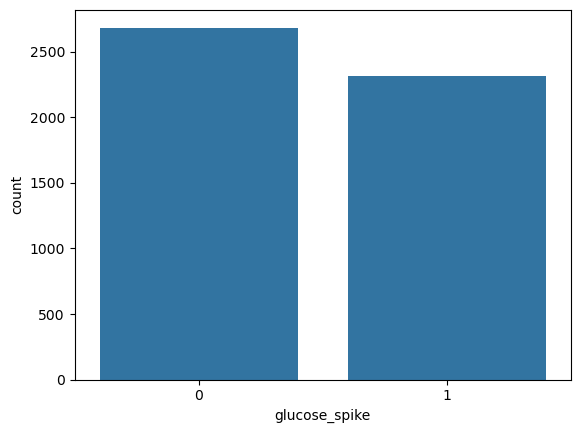

In [63]:
sns.countplot(x=df['glucose_spike'])

No need to balance or oversample data at this moment

Final Dataset ready for Model Training

In [64]:
# Save cleaned dataset
df.to_csv('Cleaned_Glucose_Spike_balanced.csv')

## Data Splitting

We will split data into training and testing sets

In [65]:
# import model selection library
from sklearn.model_selection import train_test_split
# Separate features and Target
X = df.drop('glucose_spike', axis=1)
y= df['glucose_spike']
# Split data into train test set 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
print("Training set size:", len(X_train))
print("Testing Set Size:", len(X_test))

Training set size: 4000
Testing Set Size: 1000


In [66]:
#Train set distribution
y_train.value_counts(normalize=True)*100

glucose_spike
0    53.65
1    46.35
Name: proportion, dtype: float64

In [67]:
# test set distribution
y_test.value_counts(normalize=True)*100

glucose_spike
0    53.7
1    46.3
Name: proportion, dtype: float64

## Model Selection
- *Logistic Regression*

In [68]:
# Import relevant libraries 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# initialise model
logreg = LogisticRegression(random_state=42)
# Train Logistic regression model
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Accuracy: 0.9880
Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       537
           1       0.99      0.99      0.99       463

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



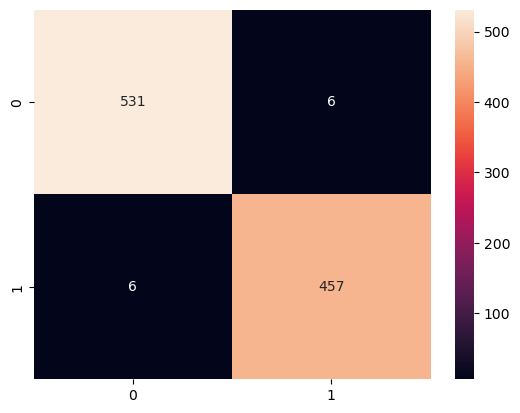

In [69]:
# Predict on test set
y_pred = logreg.predict(X_test)
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="g")
plt.show()

- *XGBoost*

In [70]:
#import XG boost library
from xgboost import XGBClassifier
xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Accuracy: 0.9840
XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       537
           1       0.98      0.98      0.98       463

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



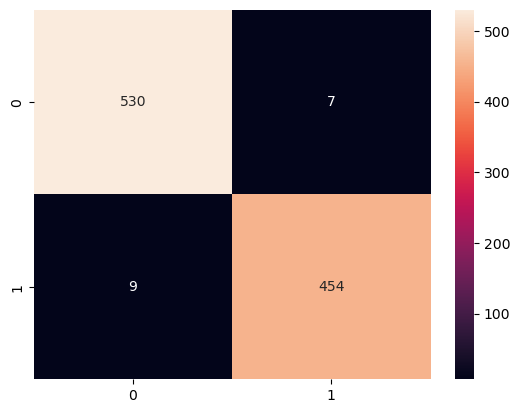

In [71]:
#predict on results
y_pred = xgb.predict(X_test)
# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="g")
plt.show()

In [72]:
## Something looks wrong, cross validation checks 
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5)
print(scores)

[0.988 0.985 0.975 0.986 0.984]


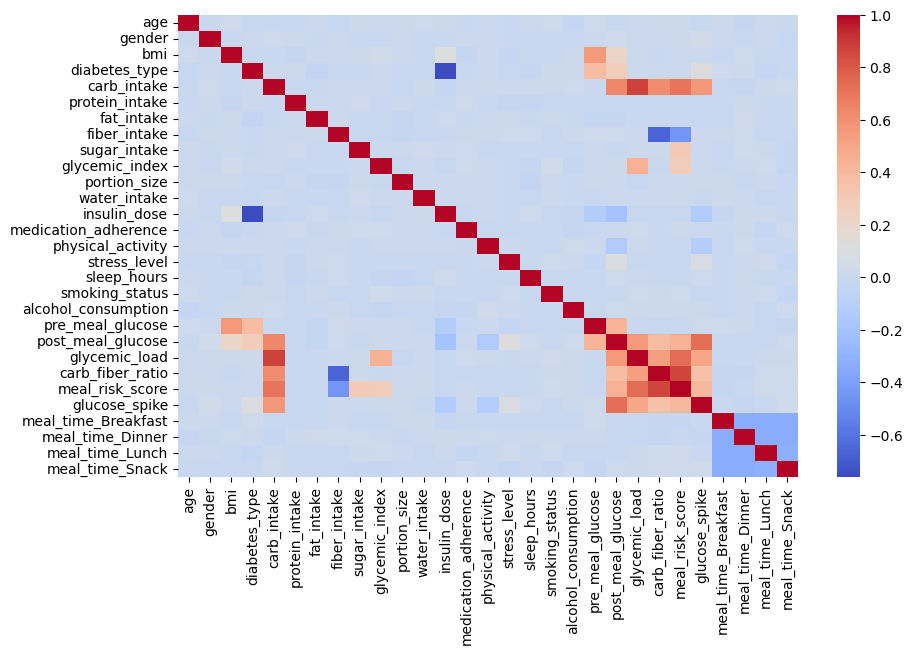

In [73]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.show()

## Hyperparameter tuning

## Model Evaluation 

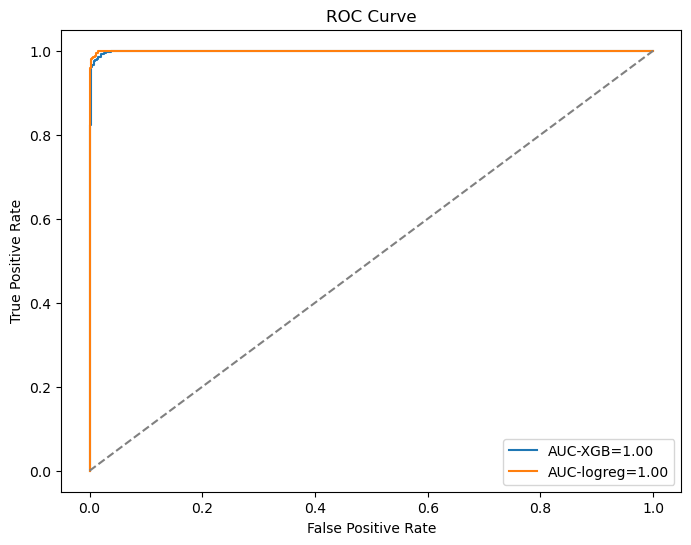

In [74]:
 # ROC Curve and AUC score
from sklearn.metrics import roc_curve, roc_auc_score
#Compute Probabilities
y_probs = xgb.predict_proba(X_test)[:,1]
y_proba = logreg.predict_proba(X_test)[:,1]
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
fpl, tpl, threshold = roc_curve(y_test, y_proba)
auc_score_xgb = roc_auc_score(y_test, y_probs)
auc_score_logreg = roc_auc_score(y_test, y_proba)
#Plot curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC-XGB={auc_score_xgb:.2f}")
plt.plot(fpl, tpl, label=f"AUC-logreg={auc_score_logreg:.2f}")
plt.plot([0,1], [0, 1], linestyle='--', color = 'gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Saving the Model

In [75]:
xgb.save_model("xgb_glucose_spike_model.json")
print("XGB Model Saved Succesfully")
import joblib
joblib.dump(logreg, "glucose_spike_lr_model.pkl")
print("Logistic Regression model saved.")

XGB Model Saved Succesfully
Logistic Regression model saved.
